This notebook is used to calculate the relationships between diseases and drugs from a molecular point of view, considering
individual diseases and agglomereted trajectories

In [1]:
import pandas as pd
import pickle as pk
import networkx as nx
import collections
import random as rd
import itertools as it
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from scipy.stats import pearsonr, spearmanr
import xml.etree.ElementTree as ET
import time

from scipy.stats import ttest_ind
import itertools
dB_file = 'input/DrugBank_FullDatabase.xml'
organism = 'Humans'
xtree = ET.parse(dB_file)
xroot = xtree.getroot()


#This method is described here:
#https://github.com/dhimmel/drugbank/blob/gh-pages/parse.ipynb

In [2]:
def fisher_test(lstA, lstB,background):
    import scipy.stats as stats
    """
    Accepts to lists
    M is the population size (previously N)
    n is the number of successes in the population
    N is the sample size (previously n)
    x is still the number of drawn “successes”
    """
    setA= set(lstA)
    setB= set(lstB)
    M= background
    n= len(setA)
    N= len(setB)
    x= len(setA.intersection(setB))

    return str(stats.hypergeom.sf(x-1, M, n, N))

import scipy  
from scipy import stats

#Here we define the adjustment
from statsmodels.sandbox.stats.multicomp import multipletests
def fdr_adjustment(list_of_pvals,alpha):    
    return multipletests(list_of_pvals,alpha=alpha,method='fdr_bh')[1] #the benjamin hochberg method is used

In [3]:
def collapse_list_values(row):
    for key, value in row.items():
        if isinstance(value, list):
            row[key] = '|'.join(value)
    return row


In [4]:
#Let's import the ICD-name dictionary
disease_name_consensus_df = pd.read_csv("output/disease_name_consensus_official_names.tsv",sep="\t")

In [84]:
import collections

# Define namespace
ns = '{http://www.drugbank.ca}'
inchikey_template = "{ns}calculated-properties/{ns}property[{ns}kind='InChIKey']/{ns}value"
inchi_template = "{ns}calculated-properties/{ns}property[{ns}kind='InChI']/{ns}value"

rows = list()

for i, drug in enumerate(xroot):
    row = collections.OrderedDict()
    assert drug.tag == ns + 'drug'
    
    # --- Basic Info ---
    row['type'] = drug.get('type')
    row['drugbank_id'] = drug.findtext(ns + "drugbank-id[@primary='true']")
    row['name'] = drug.findtext(ns + "name")
    row['description'] = drug.findtext(ns + "description")
    row['groups'] = [group.text for group in
        drug.findall("{ns}groups/{ns}group".format(ns=ns))]
    row['atc_codes'] = [code.get('code') for code in
        drug.findall("{ns}atc-codes/{ns}atc-code".format(ns=ns))]
    row['categories'] = [x.findtext(ns + 'category') for x in
        drug.findall("{ns}categories/{ns}category".format(ns=ns))]
    row['inchi'] = drug.findtext(inchi_template.format(ns=ns))
    row['inchikey'] = drug.findtext(inchikey_template.format(ns=ns))
    row['indication'] = drug.findtext(ns + "indication")
    row['mechanism-of-action'] = drug.findtext(ns + "mechanism-of-action")

    # --- Aliases ---
    aliases = {
        elem.text for elem in 
        drug.findall("{ns}international-brands/{ns}international-brand".format(ns=ns)) +
        drug.findall("{ns}synonyms/{ns}synonym[@language='English']".format(ns=ns)) +
        drug.findall("{ns}products/{ns}product/{ns}name".format(ns=ns))
    }
    if row['name']:
        aliases.add(row['name'])
    row['aliases'] = sorted(list(aliases))

    # --- NEW: Extract Targets & Genes ---
    # Targets are listed under <targets> -> <target>
    # The actual gene info is usually inside <polypeptide>
    targets = []
    target_gene_names = []
    
    # Iterate over all targets (e.g., enzymes, transporters, carriers, etc.)
    # Note: You can specifically look for "{ns}targets/{ns}target" if you only want pharmacological targets
    target_types = ['targets', 'enzymes', 'carriers', 'transporters']
    
    for t_type in target_types:
        for target in drug.findall(f"{ns}{t_type}/{ns}{t_type[:-1]}"): # e.g. targets/target
            
            # 1. Get Target Name (e.g., "Estrogen receptor alpha")
            t_name = target.findtext(ns + "name")
            
            # 2. Get Gene Name and UniProt ID (inside polypeptide)
            # Many targets have a <polypeptide> child containing the sequence/gene info
            polypeptide = target.find(ns + "polypeptide")
            
            gene_name = None
            uniprot_id = None
            
            if polypeptide is not None:
                # Extract Gene Name (e.g., "ESR1")
                gene_name = polypeptide.findtext(ns + "gene-name")
                
                # Extract UniProt ID (useful for mapping)
                # It is stored as an external-identifier
                for ext_id in polypeptide.findall(f"{ns}external-identifiers/{ns}external-identifier"):
                    resource = ext_id.findtext(ns + "resource")
                    if resource == "UniProtKB":
                        uniprot_id = ext_id.findtext(ns + "identifier")
                        break
            
            # Add to lists
            if t_name: 
                targets.append(t_name)
            if gene_name:
                target_gene_names.append(gene_name)

    row['targets'] = targets
    row['target_genes'] = target_gene_names
    
    rows.append(row)

In [85]:
columns = ['drugbank_id', 'name', 'type', 'indication','mechanism-of-action','groups', 'atc_codes', 'categories', 'inchikey', 'inchi', 'description','targets','target_genes']
drugbank_df = pd.DataFrame.from_dict(rows)[columns]
drugbank_df.head()


,drugbank_id,name,type,indication,mechanism-of-action,groups,atc_codes,categories,inchikey,inchi,description,targets,target_genes
0,DB00001,Lepirudin,biotech,For the treatment of heparin-induced thrombocy...,Lepirudin forms a stable non-covalent complex ...,[approved],[B01AE02],"[Amino Acids, Peptides, and Proteins, Anticoag...",None,None,Lepirudin is identical to natural hirudin exce...,[Prothrombin],[F2]
1,DB00002,Cetuximab,biotech,"Cetuximab, used in combination with irinotecan...",Cetuximab binds to the epidermal growth factor...,[approved],[L01XC06],"[Amino Acids, Peptides, and Proteins, Antibodi...",None,None,Cetuximab is an epidermal growth factor recept...,"[Epidermal growth factor receptor, Low affinit...","[EGFR, FCGR3B, C1R, C1QA, C1QB, C1QC, FCGR3A, ..."
2,DB00003,Dornase alfa,biotech,Used as adjunct therapy in the treatment of cy...,Dornase alfa is a biosynthetic form of human D...,[approved],[R05CB13],"[Amino Acids, Peptides, and Proteins, Cough an...",None,None,Dornase alfa is a biosynthetic form of human d...,[DNA],[]
3,DB00004,Denileukin diftitox,biotech,For treatment of cutaneous T-cell lymphoma,Denileukin diftitox binds to the high-affinity...,"[approved, investigational]",[L01XX29],"[ADP Ribose Transferases, Amino Acids, Peptide...",None,None,A recombinant DNA-derived cytotoxic protein co...,"[Interleukin-2 receptor subunit alpha, Interle...","[IL2RA, IL2RB, IL2RG]"
4,DB00005,Etanercept,biotech,Etanercept is indicated for the treatment of m...,There are two distinct receptors for TNF (TNFR...,"[approved, investigational]",[L04AB01],"[Amino Acids, Peptides, and Proteins, Analgesi...",None,None,Dimeric fusion protein consisting of the extra...,"[Tumor necrosis factor, Tumor necrosis factor ...","[TNF, TNFRSF1B, FCGR1A, FCGR3A, FCGR2A, FCGR2B..."


In [86]:
#Let's focus only on the approved drugs
drugbank_approved_df = drugbank_df[
    drugbank_df.groups.map(lambda x: 'approved' in x) ]
drugbank_approved_df.head()

,drugbank_id,name,type,indication,mechanism-of-action,groups,atc_codes,categories,inchikey,inchi,description,targets,target_genes
0,DB00001,Lepirudin,biotech,For the treatment of heparin-induced thrombocy...,Lepirudin forms a stable non-covalent complex ...,[approved],[B01AE02],"[Amino Acids, Peptides, and Proteins, Anticoag...",None,None,Lepirudin is identical to natural hirudin exce...,[Prothrombin],[F2]
1,DB00002,Cetuximab,biotech,"Cetuximab, used in combination with irinotecan...",Cetuximab binds to the epidermal growth factor...,[approved],[L01XC06],"[Amino Acids, Peptides, and Proteins, Antibodi...",None,None,Cetuximab is an epidermal growth factor recept...,"[Epidermal growth factor receptor, Low affinit...","[EGFR, FCGR3B, C1R, C1QA, C1QB, C1QC, FCGR3A, ..."
2,DB00003,Dornase alfa,biotech,Used as adjunct therapy in the treatment of cy...,Dornase alfa is a biosynthetic form of human D...,[approved],[R05CB13],"[Amino Acids, Peptides, and Proteins, Cough an...",None,None,Dornase alfa is a biosynthetic form of human d...,[DNA],[]
3,DB00004,Denileukin diftitox,biotech,For treatment of cutaneous T-cell lymphoma,Denileukin diftitox binds to the high-affinity...,"[approved, investigational]",[L01XX29],"[ADP Ribose Transferases, Amino Acids, Peptide...",None,None,A recombinant DNA-derived cytotoxic protein co...,"[Interleukin-2 receptor subunit alpha, Interle...","[IL2RA, IL2RB, IL2RG]"
4,DB00005,Etanercept,biotech,Etanercept is indicated for the treatment of m...,There are two distinct receptors for TNF (TNFR...,"[approved, investigational]",[L04AB01],"[Amino Acids, Peptides, and Proteins, Analgesi...",None,None,Dimeric fusion protein consisting of the extra...,"[Tumor necrosis factor, Tumor necrosis factor ...","[TNF, TNFRSF1B, FCGR1A, FCGR3A, FCGR2A, FCGR2B..."


In [90]:
drugbank_approved_df[drugbank_approved_df["name"]=="Ginseng"]

,drugbank_id,name,type,indication,mechanism-of-action,groups,atc_codes,categories,inchikey,inchi,description,targets,target_genes
1346,DB01404,Ginseng,small molecule,,,"[approved, investigational, nutraceutical]",[],"[COX Inhibitors, COX-2 Inhibitors, Herbs and N...",None,None,Ginseng is promoted as an adaptogen (a product...,"[Interleukin-6, Prostaglandin G/H synthase 2, ...","[IL6, PTGS2, AHR]"


In [23]:
#Let's extract the drug indications of approved drugs for ICD-10 terms
disease_approveddrugs_dict = {}
for i,v in disease_name_consensus_df.iterrows():
    icd_code = v['ICD']
    icd_consensus_name = v['PubMed_query_name'].lower()
    icd_name_list = v['Disease Name'].lower().split(";")
    drug_list = []

    for i,v in drugbank_approved_df.iterrows():
        indication = v['indication'].lower()
        drug_name = v['name']
        if icd_consensus_name in indication:
            drug_list.append(drug_name)
        for icd_name in icd_name_list:
            if icd_name in indication:
                drug_list.append(drug_name)
    if len(drug_list)>0:
        disease_approveddrugs_dict[icd_code] = drug_list

print(len(disease_approveddrugs_dict))

325


In [26]:

with open('output/disease_approveddrugs_dict_2026_official.pickle', 'wb') as handle:
    pk.dump(disease_approveddrugs_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [88]:
#This is the total list of drugs that will be used as background of the Fisher's exact test for future comparisons
tot_drug_list = []

for drug_list in list(disease_approveddrugs_dict.values()):
    for drg in drug_list:
        if drg not in tot_drug_list:
            tot_drug_list.append(drg)
print(len(tot_drug_list))

1530


In [89]:
import ast

# Safely evaluate string representations of lists into actual lists
drugbank_approved_df['target_genes'] = drugbank_approved_df['target_genes'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

fda_approved_drug_to_genes_dict = {
    row['name']: row['target_genes']
    for index, row in drugbank_approved_df.iterrows()
    if isinstance(row['target_genes'], list) and len(row['target_genes']) > 0
}
len(fda_approved_drug_to_genes_dict)

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_37892/3611210027.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drugbank_approved_df['target_genes'] = drugbank_approved_df['target_genes'].apply(


2253

In [29]:
#Let's import the trajectories
with open('output/male_trajectories_dict_filtered_unique_v2026_official.pickle', 'rb') as handle:
    male_trajectories_dict_filtered_unique = pk.load(handle)
    
with open('output/female_trajectories_dict_filtered_unique_v2026_official.pickle', 'rb') as handle:
    female_trajectories_dict_filtered_unique = pk.load(handle)


In [14]:
#Let's import the epidemiological networks

G_elma_icd_female_df = pd.read_csv('output/G_elma_icd_female_df_v2026_official.tsv', sep="\t",index_col=0)
G_elma_icd_male_df = pd.read_csv('output/G_elma_icd_male_df_v2026_official.tsv', sep="\t",index_col=0)

#Let's import the genetic network
G_gene_icd_disp_significant_post_df = pd.read_csv("output/G_gene_icd_disp_significant_post_df_v2026_official.tsv", sep="\t",index_col=0)
G_gene_icd_disp_significant_post = nx.from_pandas_edgelist(G_gene_icd_disp_significant_post_df, 'Dis A', 'Dis B')

In [30]:
#Let's filter by keeping only those trajectories that had at least one associated drug
male_trajectories_dict_filtered_unique_with_drugs_dict = {}
for trj,dislist in male_trajectories_dict_filtered_unique.items():
    new_dislist = set(dislist) & set(disease_approveddrugs_dict.keys())
    if len(new_dislist)>1:
        male_trajectories_dict_filtered_unique_with_drugs_dict[trj] = new_dislist
        
print(len(male_trajectories_dict_filtered_unique_with_drugs_dict))

150


In [31]:
#Let's check the number of unique trajectories that share at least one drugs across all pairwise comparisons

male_trj_with_atleast_one_common_drug_across_all_pairwise = []

for trj, disset in male_trajectories_dict_filtered_unique_with_drugs_dict.items():
    dis_list = list(disset)
    
    # 1. Skip trajectories with fewer than 2 diseases (cannot have a 'pair')
    if len(dis_list) < 2:
        continue
        
    pairwise_comb = it.combinations(dis_list, 2)
    
    # 2. Use 'all()' for a strict "Universal Overlap" condition.
    # This will 'short-circuit' (stop early) if any pair has zero overlap.
    all_pairs_overlap = all(
        len(set(disease_approveddrugs_dict[dis1]) & set(disease_approveddrugs_dict[dis2])) > 0
        for dis1, dis2 in pairwise_comb
    )
    
    if all_pairs_overlap:
        male_trj_with_atleast_one_common_drug_across_all_pairwise.append(trj)

print(f"Total trajectories with universal pairwise overlap: {len(male_trj_with_atleast_one_common_drug_across_all_pairwise)}")

Total trajectories with universal pairwise overlap: 24


In [32]:

# Let's check the number of unique trajectories that have at least one 
# statistically significant drug overlap across any disease pairwise combination
male_trj_with_atleast_one_significant_shared_drug = []

for trj, disset in male_trajectories_dict_filtered_unique_with_drugs_dict.items():
    # Convert set to list to ensure order for combinations
    dis_list = list(disset)
    
    # Only process if there are at least 2 diseases to compare
    if len(dis_list) < 2:
        continue
        
    pairwise_comb = list(it.combinations(dis_list, 2))
    p_values = []
    pair_keys = []
    
    # 1. Calculate all Fisher P-values for the pairs in this trajectory
    for dis1, dis2 in pairwise_comb:
        p_val = float(fisher_test(
            disease_approveddrugs_dict[dis1],
            disease_approveddrugs_dict[dis2],
            len(tot_drug_list)
        ))
        p_values.append(p_val)
        pair_keys.append((dis1, dis2))
        
    # 2. Apply FDR adjustment across all pairs within this trajectory
    adj_p_values = fdr_adjustment(p_values, 0.05)
    
    # 3. Check if ANY pair meets the significance threshold
    # We use 'any' for efficiency; as soon as one is < 0.05, we can stop.
    is_significant = any(fdr < 0.05 for fdr in adj_p_values)

    if is_significant:
        male_trj_with_atleast_one_significant_shared_drug.append(trj)

print(f"Number of trajectories: {len(male_trj_with_atleast_one_significant_shared_drug)}")


Number of trajectories: 42


In [33]:
for el in male_trj_with_atleast_one_common_drug_across_all_pairwise:
    print(el,set.intersection(*map(set,[disease_approveddrugs_dict[dis] for dis in male_trajectories_dict_filtered_unique_with_drugs_dict[el]])))

15_73 {'Glipizide', 'Miglitol', 'Tolbutamide'}
39 {'Bismuth Subcitrate'}
55 {'Molindone', 'Quetiapine', 'Prochlorperazine', 'Olanzapine', 'Perphenazine', 'Fluphenazine', 'Aripiprazole', 'Chlorprothixene', 'Aripiprazole lauroxil', 'Loxapine', 'Ziprasidone'}
72 {'Calcitriol', 'Cholecalciferol', 'Calcidiol'}
77 {'Molindone', 'Quetiapine', 'Prochlorperazine', 'Olanzapine', 'Perphenazine', 'Fluphenazine', 'Aripiprazole', 'Chlorprothixene', 'Aripiprazole lauroxil', 'Loxapine', 'Ziprasidone'}
82_87 {'Amisulpride', 'Asenapine', 'Armodafinil', 'Pimavanserin'}
99 {'Meropenem'}
140 {'Metoprolol'}
184 {'Lipegfilgrastim'}
186 {'Fluorouracil'}
209 {'Dabigatran etexilate'}
215 {'Hyaluronic acid'}
217 {'Metoprolol'}
233 {'Sucralfate', 'Omeprazole', 'Homatropine Methylbromide', 'Nizatidine', 'Roxatidine acetate', 'Pirenzepine'}
281 {'Ciprofloxacin', 'Enoxacin'}
301_353 {'Levodopa'}
318 {'Phenindione', 'Warfarin'}
330 {'Fluorouracil'}
364 {'Ciprofloxacin', 'Enoxacin'}
369 {'Sipuleucel-T', 'Ixabepilone',

In [34]:
male_trajectories_dict_filtered_unique_with_drugs_dict['39']

{'K21', 'K29'}

In [36]:
#Let's do the same for females
female_trajectories_dict_filtered_unique_with_drugs_dict = {}
for trj,dislist in female_trajectories_dict_filtered_unique.items():
    new_dislist = set(dislist) & set(disease_approveddrugs_dict.keys())
    if len(new_dislist)>1:
        female_trajectories_dict_filtered_unique_with_drugs_dict[trj] = new_dislist
        
print(len(female_trajectories_dict_filtered_unique_with_drugs_dict))

142


In [37]:
#Let's check the number of unique trajectories that share at least one drugs across all pairwise comparisons

female_trj_with_atleast_one_common_drug_across_all_pairwise = []
for trj,disset in female_trajectories_dict_filtered_unique_with_drugs_dict.items():
    pairwise_comb = list(it.combinations(list(disset),2))
    drug_intersecton_list = []
    for dis1,dis2 in pairwise_comb:
        drug_intersection = set(disease_approveddrugs_dict[dis1]) & set(disease_approveddrugs_dict[dis2])
        if len(drug_intersection)>0:
            drug_intersecton_list.append((dis1,dis2))
    if len(drug_intersecton_list)==len(pairwise_comb):
        female_trj_with_atleast_one_common_drug_across_all_pairwise.append(trj)
        

print(len(female_trj_with_atleast_one_common_drug_across_all_pairwise))

22


In [38]:

# Let's check the number of unique trajectories that have at least one 
# statistically significant drug overlap across any disease pairwise combination
female_trj_with_atleast_one_significant_shared_drug = []

for trj, disset in female_trajectories_dict_filtered_unique_with_drugs_dict.items():
    # Convert set to list to ensure order for combinations
    dis_list = list(disset)
    
    # Only process if there are at least 2 diseases to compare
    if len(dis_list) < 2:
        continue
        
    pairwise_comb = list(it.combinations(dis_list, 2))
    p_values = []
    pair_keys = []
    
    # 1. Calculate all Fisher P-values for the pairs in this trajectory
    for dis1, dis2 in pairwise_comb:
        p_val = float(fisher_test(
            disease_approveddrugs_dict[dis1],
            disease_approveddrugs_dict[dis2],
            len(tot_drug_list)
        ))
        p_values.append(p_val)
        pair_keys.append((dis1, dis2))
        
    # 2. Apply FDR adjustment across all pairs within this trajectory
    adj_p_values = fdr_adjustment(p_values, 0.05)
    
    # 3. Check if ANY pair meets the significance threshold
    # We use 'any' for efficiency; as soon as one is < 0.05, we can stop.
    is_significant = any(fdr < 0.05 for fdr in adj_p_values)

    if is_significant:
        female_trj_with_atleast_one_significant_shared_drug.append(trj)

print(f"Number of trajectories: {len(female_trj_with_atleast_one_significant_shared_drug)}")


Number of trajectories: 45


In [39]:


male_trajectories_dict_filtered_unique_with_drugs_df = pd.DataFrame()

trj_list = []
dis_list = []
drug_list = []

for trj,disset in male_trajectories_dict_filtered_unique_with_drugs_dict.items():
    trj_list.append(trj)
    dis_list.append(str(disset))
    dg_list = []
    for dis in disset:
        dg_list.extend(disease_approveddrugs_dict[dis])
        
    drug_list.append(str(dict(Counter(dg_list))))

male_trajectories_dict_filtered_unique_with_drugs_df["Trajectory"] = trj_list
male_trajectories_dict_filtered_unique_with_drugs_df["Disease list"] = dis_list
male_trajectories_dict_filtered_unique_with_drugs_df["Drug Indications"] = drug_list

male_trajectories_dict_filtered_unique_with_drugs_df.head()

male_trajectories_dict_filtered_unique_with_drugs_df.to_csv("output/SuppTab6_male_trj_drug_indications_v2026_official.csv")

In [40]:


female_trajectories_dict_filtered_unique_with_drugs_df = pd.DataFrame()

trj_list = []
dis_list = []
drug_list = []

for trj,disset in female_trajectories_dict_filtered_unique_with_drugs_dict.items():
    trj_list.append(trj)
    dis_list.append(str(disset))
    dg_list = []
    for dis in disset:
        dg_list.extend(disease_approveddrugs_dict[dis])
        
    drug_list.append(str(dict(Counter(dg_list))))

female_trajectories_dict_filtered_unique_with_drugs_df["Trajectory"] = trj_list
female_trajectories_dict_filtered_unique_with_drugs_df["Disease list"] = dis_list
female_trajectories_dict_filtered_unique_with_drugs_df["Drug Indications"] = drug_list

female_trajectories_dict_filtered_unique_with_drugs_df.head()

female_trajectories_dict_filtered_unique_with_drugs_df.to_csv("output/SuppTab6_female_trj_drug_indications_v2026_official.csv")

In [12]:
female_trajectories_dict_filtered_unique_with_drugs_df = pd.read_csv("output/SuppTab6_female_trj_drug_indications_v2026_official.csv")

In [17]:
for i,v in female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.iterrows():
    trj = v['Trajectory']
    drug = v['Drug']
    sub_approved_df = female_trajectories_dict_filtered_unique_with_drugs_df[female_trajectories_dict_filtered_unique_with_drugs_df['Trajectory']==trj]
    try:
        drug_indications = sub_approved_df['Drug Indications'].iloc[0]
        if drug in drug_indications:
            print(trj,drug,drug_indications)
    except:
        pass
                                                                                

1 Tramadol {'Tramadol': 1, 'Lactulose': 1, 'Lubiprostone': 1, 'Tegaserod': 1, 'Magnesium oxide': 1, 'Prucalopride': 1, 'Methylnaltrexone': 1, 'Linaclotide': 1, 'Naloxegol': 1, 'Potassium alum': 1, 'Magnesium hydroxide': 1, 'Bisoxatin': 1, 'Polyethylene glycol': 1, 'Polycarbophil': 1, 'Magnesium acetate tetrahydrate': 1, 'Sodium phosphate': 1, 'Docusate': 1, 'Plantago seed': 1, 'Magnesium citrate': 1, 'Methyl cellulose': 1, 'Sennosides': 1, 'Naldemedine': 1, 'Galactose': 1, 'Ceruletide': 1, 'Ivermectin': 1, 'Trimebutine': 1, 'Dexpanthenol': 1, 'Moxidectin': 1}
1 Methylnaltrexone {'Tramadol': 1, 'Lactulose': 1, 'Lubiprostone': 1, 'Tegaserod': 1, 'Magnesium oxide': 1, 'Prucalopride': 1, 'Methylnaltrexone': 1, 'Linaclotide': 1, 'Naloxegol': 1, 'Potassium alum': 1, 'Magnesium hydroxide': 1, 'Bisoxatin': 1, 'Polyethylene glycol': 1, 'Polycarbophil': 1, 'Magnesium acetate tetrahydrate': 1, 'Sodium phosphate': 1, 'Docusate': 1, 'Plantago seed': 1, 'Magnesium citrate': 1, 'Methyl cellulose': 1,

In [44]:
#Let's import the genetic enad the epidemiolgoical networks
G_elma_icd_female_df = pd.read_csv('output/G_elma_icd_female_df_v2026_official.tsv', sep="\t",index_col=0)
G_elma_icd_female_nx = nx.from_pandas_edgelist(G_elma_icd_female_df, 'Dis A', 'Dis B')
G_elma_icd_male_df = pd.read_csv('output/G_elma_icd_male_df_v2026_official.tsv', sep="\t",index_col=0)
G_elma_icd_male_nx = nx.from_pandas_edgelist(G_elma_icd_male_df, 'Dis A', 'Dis B')

#Let's import the genetic network
G_gene_icd_disp_significant_post_df = pd.read_csv("output/G_gene_icd_disp_significant_post_df_v2026_official.tsv", sep="\t",index_col=0)
G_gene_icd_disp_significant_post = nx.from_pandas_edgelist(G_gene_icd_disp_significant_post_df, 'Dis A', 'Dis B')

In [78]:
#Let's import the Genetic Heridatability Predictions from https://h2.cpr.ku.dk/icd10rglvl3.php

heritability_df = pd.read_csv("input/website_icd10_rg_lvl3.tsv", sep="\t")
ICD_heritability = {}
for i,v in heritability_df.iterrows():
    ICD_heritability[v['A'],v['B']] = v['X50_']

In [45]:
epidemiological_disease_pairs = set(G_elma_icd_female_nx.edges()).union(set(G_elma_icd_male_nx.edges()))
genetic_disease_pairs = set(G_gene_icd_disp_significant_post.edges())


genetic_epidemiological_disease_pairs = []
genetic_disease_pairs_only = []
for dis_pair in genetic_disease_pairs:
    if dis_pair in epidemiological_disease_pairs or (dis_pair[1],dis_pair[0]) in epidemiological_disease_pairs:
        genetic_epidemiological_disease_pairs.append(dis_pair)
    else:
        genetic_disease_pairs_only.append(dis_pair)

epidemiological_disease_pairs_only = []
for dis_pair in epidemiological_disease_pairs:
    if dis_pair not in genetic_disease_pairs and (dis_pair[1],dis_pair[0]) not in genetic_disease_pairs:
        epidemiological_disease_pairs_only.append(dis_pair)


In [46]:
#Let's compare the heridatibility of disease pairs that:
# 1. share a genetic and epidemiological component 
# 2. share a genetic component only
# 3. share an epidemiological component only
# 4. do not share anything


genetic_epidemiological_disease_pairs_heritability = []
genetic_only_disease_pairs_heritability = []
epidemiological_only_disease_pairs_heritability = []
for dis_pair in genetic_epidemiological_disease_pairs:
    try:
        try:
            genetic_epidemiological_disease_pairs_heritability.append(ICD_heritability[dis_pair])
        except:
            genetic_epidemiological_disease_pairs_heritability.append(ICD_heritability[dis_pair[1],dis_pair[0]])
    except:
        pass
            
for dis_pair in genetic_disease_pairs_only:
    try:
        try:
            genetic_only_disease_pairs_heritability.append(ICD_heritability[dis_pair])
        except:
            genetic_only_disease_pairs_heritability.append(ICD_heritability[dis_pair[1],dis_pair[0]])
    except:
        pass

for dis_pair in epidemiological_disease_pairs_only:
    try:
        try:
            epidemiological_only_disease_pairs_heritability.append(ICD_heritability[dis_pair])
        except:
            epidemiological_only_disease_pairs_heritability.append(ICD_heritability[dis_pair[1],dis_pair[0]])
    except:
        pass

In [81]:
len(genetic_epidemiological_disease_pairs_heritability)

106

In [82]:
median_genetic_epidemiological = np.median(genetic_epidemiological_disease_pairs_heritability)
median_genetic_only = np.median(genetic_only_disease_pairs_heritability)
median_epidemiological_only = np.median(epidemiological_only_disease_pairs_heritability)

median_rd_genetic_epidemiological_list = []
median_rd_genetic_only_list = [] 
median_rd_epidemiological_only_list = []
for i in range(1000):
    median_rd_genetic_epidemiological_list.append(np.median(rd.sample(list(ICD_heritability.values()),len(genetic_epidemiological_disease_pairs_heritability))))
    median_rd_genetic_only_list.append(np.median(rd.sample(list(ICD_heritability.values()),len(genetic_only_disease_pairs_heritability))))
    median_rd_epidemiological_only_list.append(np.median(rd.sample(list(ICD_heritability.values()),len(epidemiological_only_disease_pairs_heritability))))


In [83]:
import numpy as np

def zscore(obs, rand):
    rand = np.asarray(rand)
    return (obs - rand.mean()) / rand.std(ddof=1)

z_gen_epi = zscore(median_genetic_epidemiological,
                   median_rd_genetic_epidemiological_list)

z_gen_only = zscore(median_genetic_only,
                    median_rd_genetic_only_list)

z_epi_only = zscore(median_epidemiological_only,
                    median_rd_epidemiological_only_list)

print(f"Z (genetic + epidemiological): {z_gen_epi:.2f}")
print(f"Z (genetic only): {z_gen_only:.2f}")
print(f"Z (epidemiological only): {z_epi_only:.2f}")

Z (genetic + epidemiological): 17.75
Z (genetic only): 6.75
Z (epidemiological only): 21.27


In [84]:
def plot_random_vs_observed(rand_list, obs_value, title):
    rand_log = np.log10(rand_list)
    obs_log = np.log10(obs_value)

    z = (obs_value - np.mean(rand_list)) / np.std(rand_list, ddof=1)

    fig, ax = plt.subplots(figsize=(5, 4))

    ax.hist(rand_log, bins=25, density=True, alpha=0.6)
    ax.axvline(obs_log, linestyle="--", linewidth=2,
               label=f"Observed (z={z:.2f})")

    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Density")
    ax.set_xlabel("Median heritability")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.3)

    # Replace tick labels
    ticks = ax.get_xticks()
    nice_labels = []
    for t in ticks:
        if np.isfinite(t):
            real = 10 ** t
            if real < 1:
                nice_labels.append(f"{real:.2f}")
            elif real < 1000:
                nice_labels.append(f"{real:.1f}")
            else:
                nice_labels.append(f"{real:.0f}")
        else:
            nice_labels.append("")
    ax.set_xticklabels(nice_labels)

    fig.tight_layout()
    return fig, ax

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_32471/1678516453.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nice_labels)
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_32471/1678516453.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nice_labels)
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_32471/1678516453.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nice_labels)


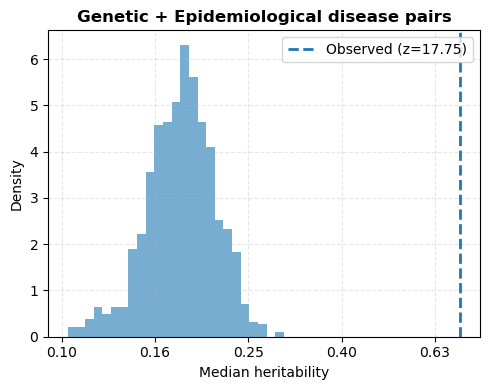

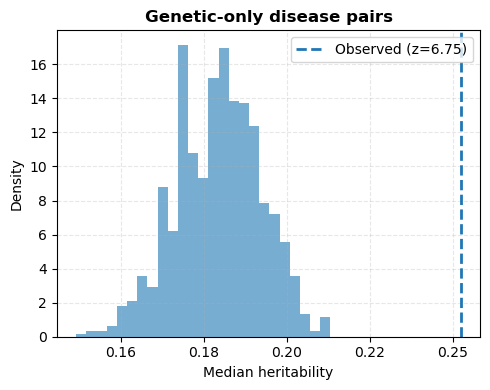

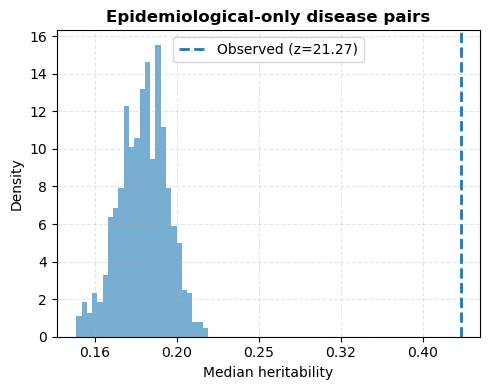

In [85]:
fig, ax = plot_random_vs_observed(
    median_rd_genetic_epidemiological_list,
    median_genetic_epidemiological,
    "Genetic + Epidemiological disease pairs"
)

fig.savefig(
    "Figures/SF8A_Hereditability_Genetic_Epidemiological_DisPairs_v2026_official.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)


fig, ax = plot_random_vs_observed(
    median_rd_genetic_only_list,
    median_genetic_only,
    "Genetic-only disease pairs"
)

fig.savefig(
    "Figures/SF8B_Hereditability_Genetic_DisPairs_v2026_official.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)


fig, ax = plot_random_vs_observed(
    median_rd_epidemiological_only_list,
    median_epidemiological_only,
    "Epidemiological-only disease pairs"
)

fig.savefig(
    "Figures/SF8C_Hereditability_Epidemiological_DisPairs_v2026_official.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_32471/1664710145.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_32471/1664710145.py:26: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


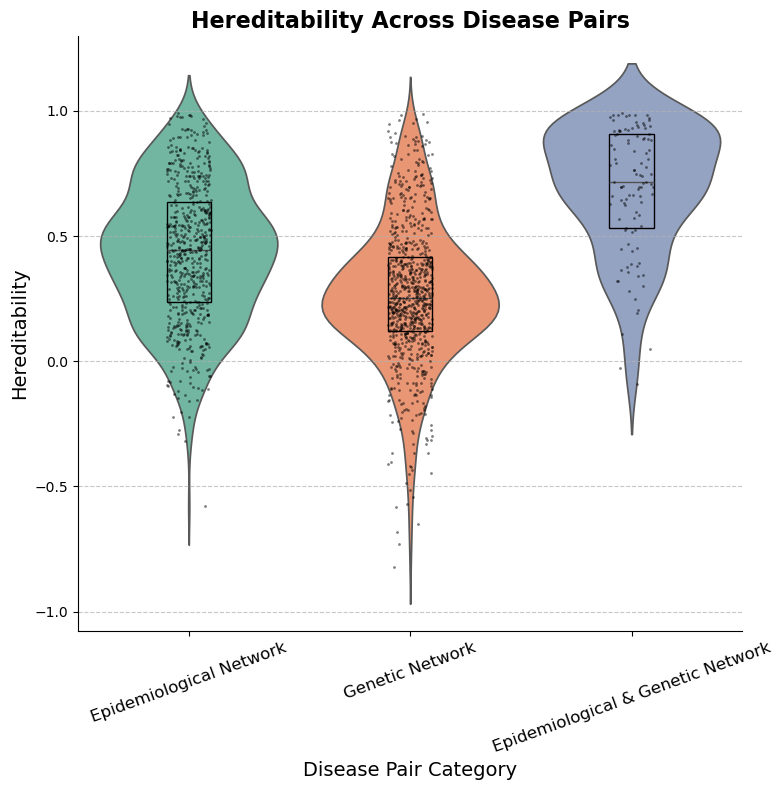

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure fonts remain editable
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

# Prepare tidy data
data = {
    "Epidemiological Network": epidemiological_only_disease_pairs_heritability,
    "Genetic Network": genetic_only_disease_pairs_heritability,
    "Epidemiological & Genetic Network": genetic_epidemiological_disease_pairs_heritability
}

# Convert to long-form DataFrame
df_plot = pd.DataFrame([
    {"category": cat, "shared_drugs": val}
    for cat, values in data.items()
    for val in values
])

# Plot
plt.figure(figsize=(8, 8))
sns.violinplot(
    data=df_plot,
    x="category",
    y="shared_drugs",
    inner=None,   # no bars inside
    scale="width",
    palette="Set2"
)
sns.boxplot(
    data=df_plot,
    x="category",
    y="shared_drugs",
    width=0.2,
    showcaps=False,
    boxprops={"facecolor": "none", "edgecolor": "black"},
    showfliers=False,
    whiskerprops={"linewidth": 0}
)
sns.stripplot(
    data=df_plot,
    x="category",
    y="shared_drugs",
    color="black",
    size=2,
    alpha=0.5,
    jitter=True
)

# Labels and styling
plt.xticks(rotation=20, fontsize=12)
plt.xlabel("Disease Pair Category", fontsize=14)
plt.ylabel("Hereditability", fontsize=14)
plt.title("Hereditability Across Disease Pairs", fontsize=16, weight="bold")
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

# Save in vector formats with editable text
plt.savefig("Figures/Fig5A_hereditability_across_categories_v2026_official.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Figures/Fig5A_hereditability_across_categories_v2026_official.svg", format="svg", dpi=300, bbox_inches="tight")

plt.show()

In [87]:

data = {
    "Epidemiological Network": epidemiological_only_disease_pairs_heritability,
    "Genetic Network": genetic_only_disease_pairs_heritability,
    "Epidemiological & Genetic Network": genetic_epidemiological_disease_pairs_heritability
}

rows = []

for category, values in data.items():
    clean_values = [v for v in values if pd.notna(v)]
    for val in clean_values:
        rows.append({
            "Category": category,
            "Heritability": val,
            "metadata": None
        })

df_herit = pd.DataFrame(rows)

# Deterministic ordering
df_herit = df_herit.sort_values(["Category", "Heritability"]).reset_index(drop=True)

# -----------------------------
# 2. Add metadata rows
# -----------------------------
metadata_entries = [
    "Violin plot: scale='width', inner=None",
    "Boxplot overlay: showfliers=False, width=0.2",
    "Stripplot overlay: jitter=True, alpha=0.5, size=2",
    f"N_Epidemiological_Network: {len([v for v in data['Epidemiological Network'] if pd.notna(v)])}",
    f"N_Genetic_Network: {len([v for v in data['Genetic Network'] if pd.notna(v)])}",
    f"N_Epidemiological_&_Genetic_Network: {len([v for v in data['Epidemiological & Genetic Network'] if pd.notna(v)])}"
]

metadata_df = pd.DataFrame({
    "Category": [None]*len(metadata_entries),
    "Heritability": [None]*len(metadata_entries),
    "metadata": metadata_entries
})

source_df = pd.concat([df_herit, metadata_df], ignore_index=True)

excel_path = "output/SourceData.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a") as writer:
    source_df.to_excel(writer, sheet_name="Fig5A", index=False)

print(f"Source data saved to {excel_path}")

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_32471/2219242812.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  source_df = pd.concat([df_herit, metadata_df], ignore_index=True)


Source data saved to output/SourceData.xlsx


In [47]:
#Let's compare the number of shared drugs across all pairwise diseases vs disease pairs that are in at least one epidemiological network
#vs those pairs that are present in the genetic network and those that are in all pairs

genetic_epidemiological_disease_pairs_with_drugs = []
for dis_pair in genetic_epidemiological_disease_pairs:
    try:
        if len(set(disease_approveddrugs_dict[dis_pair[0]]) & set(disease_approveddrugs_dict[dis_pair[1]]))>0:
            genetic_epidemiological_disease_pairs_with_drugs.append(dis_pair)
    except:
        pass

genetic_disease_pairs_with_drugs = []
for dis_pair in genetic_disease_pairs_only:
    try:
        if len(set(disease_approveddrugs_dict[dis_pair[0]]) & set(disease_approveddrugs_dict[dis_pair[1]]))>0:
            genetic_disease_pairs_with_drugs.append(dis_pair)
    except:
        pass

epidemiological_disease_pairs_with_drugs = []
for dis_pair in epidemiological_disease_pairs_only:
    try:
        if len(set(disease_approveddrugs_dict[dis_pair[0]]) & set(disease_approveddrugs_dict[dis_pair[1]]))>0:
            epidemiological_disease_pairs_with_drugs.append(dis_pair)
    except:
        pass

print(len(genetic_epidemiological_disease_pairs_with_drugs))
print(len(genetic_disease_pairs_with_drugs))
print(len(epidemiological_disease_pairs_with_drugs))

52
190
43


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_37892/962957386.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_37892/962957386.py:35: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


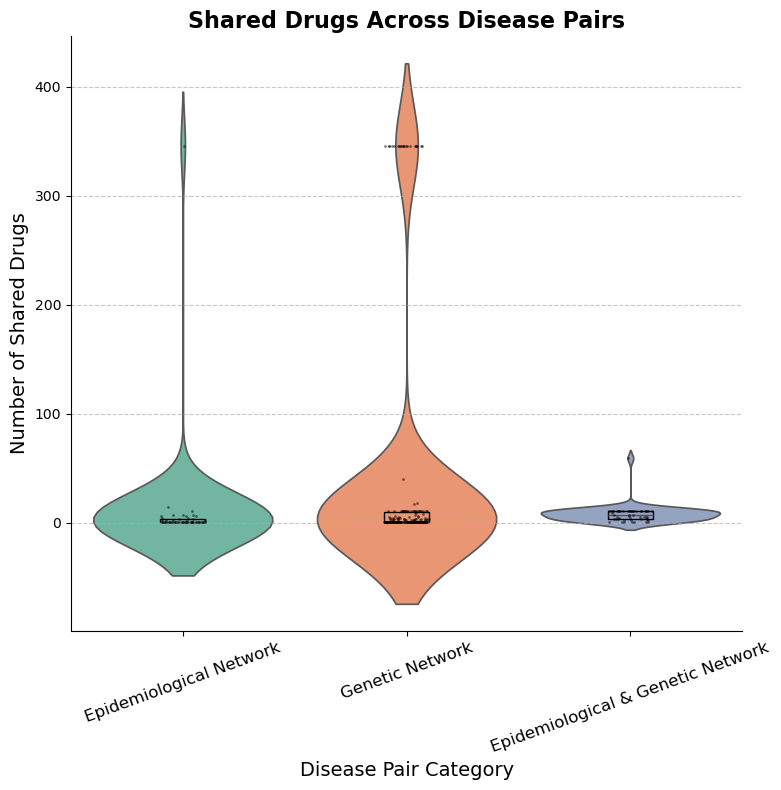

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure fonts remain editable
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

# Prepare tidy data
data = {
    "Epidemiological Network": [
        len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB]))
        for disA, disB in epidemiological_disease_pairs_with_drugs
    ],
    "Genetic Network": [
        len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB]))
        for disA, disB in genetic_disease_pairs_with_drugs
    ],
    "Epidemiological & Genetic Network": [
        len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB]))
        for disA, disB in genetic_epidemiological_disease_pairs_with_drugs
    ]
}

# Convert to long-form DataFrame
df_plot = pd.DataFrame([
    {"category": cat, "shared_drugs": val}
    for cat, values in data.items()
    for val in values
])

# Plot
plt.figure(figsize=(8, 8))
sns.violinplot(
    data=df_plot,
    x="category",
    y="shared_drugs",
    inner=None,   # no bars inside
    scale="width",
    palette="Set2"
)
sns.boxplot(
    data=df_plot,
    x="category",
    y="shared_drugs",
    width=0.2,
    showcaps=False,
    boxprops={"facecolor": "none", "edgecolor": "black"},
    showfliers=False,
    whiskerprops={"linewidth": 0}
)
sns.stripplot(
    data=df_plot,
    x="category",
    y="shared_drugs",
    color="black",
    size=2,
    alpha=0.5,
    jitter=True
)

# Labels and styling
plt.xticks(rotation=20, fontsize=12)
plt.xlabel("Disease Pair Category", fontsize=14)
plt.ylabel("Number of Shared Drugs", fontsize=14)
plt.title("Shared Drugs Across Disease Pairs", fontsize=16, weight="bold")
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

# Save in vector formats with editable text
plt.savefig("Figures/Fig5C_shareddrugs_disease_pairs_v2026_official.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Figures/Fig5C_shareddrugs_disease_pairs_v2026_official.svg", format="svg", dpi=300, bbox_inches="tight")

plt.show()

In [49]:


rows = []

def compute_shared(dis_pairs, category):
    for disA, disB in dis_pairs:
        shared = len(set(disease_approveddrugs_dict[disA]) &
                     set(disease_approveddrugs_dict[disB]))
        rows.append({
            "Category": category,
            "Disease_A": disA,
            "Disease_B": disB,
            "Shared_Drugs": shared,
            "metadata": None
        })

compute_shared(epidemiological_disease_pairs_with_drugs,
               "Epidemiological Network")

compute_shared(genetic_disease_pairs_with_drugs,
               "Genetic Network")

compute_shared(genetic_epidemiological_disease_pairs_with_drugs,
               "Epidemiological & Genetic Network")

df_shared = pd.DataFrame(rows)

# Clean ordering for deterministic export
df_shared = df_shared.sort_values(
    ["Category", "Disease_A", "Disease_B"]
).reset_index(drop=True)

# -----------------------------
# 2. Metadata rows
# -----------------------------
metadata_entries = [
    "Violin plot: scale='width', inner=None",
    "Boxplot overlay: showfliers=False, width=0.2",
    "Stripplot overlay: jitter=True, alpha=0.5, size=2",
    f"N_Epidemiological_Network: {len(epidemiological_disease_pairs_with_drugs)}",
    f"N_Genetic_Network: {len(genetic_disease_pairs_with_drugs)}",
    f"N_Epidemiological_&_Genetic_Network: {len(genetic_epidemiological_disease_pairs_with_drugs)}",
    "Shared drugs computed as intersection of approved drug sets"
]

metadata_df = pd.DataFrame({
    "Category": [None]*len(metadata_entries),
    "Disease_A": [None]*len(metadata_entries),
    "Disease_B": [None]*len(metadata_entries),
    "Shared_Drugs": [None]*len(metadata_entries),
    "metadata": metadata_entries
})

source_df = pd.concat([df_shared, metadata_df], ignore_index=True)

excel_path = "output/SourceData.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a",if_sheet_exists="replace") as writer:
    source_df.to_excel(writer, sheet_name="Fig5C", index=False)

print(f"Source data saved to {excel_path}")

Source data saved to output/SourceData.xlsx


In [50]:

from scipy.stats import ttest_ind
import itertools

# Data preparation (as before)
data = [
    [len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB])) 
     for disA, disB in epidemiological_disease_pairs_with_drugs],
    
    [len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB])) 
     for disA, disB in genetic_disease_pairs_with_drugs],
    
    [len(set(disease_approveddrugs_dict[disA]) & set(disease_approveddrugs_dict[disB])) 
     for disA, disB in genetic_epidemiological_disease_pairs_with_drugs]
]

labels = [
    "Epidemiological Network",
    "Genetic Network",
    "Epidemiological & Genetic Network"
]

# Perform pairwise t-tests
pairwise_results = {}
for (i, j) in itertools.combinations(range(len(data)), 2):
    stat, pval = ttest_ind(data[i], data[j], equal_var=False)  # Welch’s t-test
    pairwise_results[(labels[i], labels[j])] = (stat, pval)

# Print results nicely
print("Pairwise t-test results:")
for pair, (stat, pval) in pairwise_results.items():
    print(f"{pair[0]} vs {pair[1]}: t = {stat:.3f}, p = {pval:.3e}")

Pairwise t-test results:
Epidemiological Network vs Genetic Network: t = -2.738, p = 7.030e-03
Epidemiological Network vs Epidemiological & Genetic Network: t = 0.341, p = 7.351e-01
Genetic Network vs Epidemiological & Genetic Network: t = 4.222, p = 3.691e-05


In [51]:
print(np.mean(data[0]))
print(np.mean(data[1]))
print(np.mean(data[2]))


10.674418604651162
41.294736842105266
7.923076923076923


In [52]:
# Drug universe
all_drugs = set().union(*disease_approveddrugs_dict.values())
D = len(all_drugs)

def observed_overlap(disA, disB):
    return len(set(disease_approveddrugs_dict[disA]) &
               set(disease_approveddrugs_dict[disB]))

def expected_overlap(disA, disB):
    kA = len(disease_approveddrugs_dict[disA])
    kB = len(disease_approveddrugs_dict[disB])
    return (kA * kB) / D

from scipy.stats import wilcoxon, kruskal

def drug_overlap_z(disA, disB):
    kA = len(disease_approveddrugs_dict[disA])
    kB = len(disease_approveddrugs_dict[disB])
    obs = observed_overlap(disA, disB)

    exp = (kA * kB) / D
    var = (kA * kB * (D - kA) * (D - kB)) / (D**2 * (D - 1))

    return (obs - exp) / np.sqrt(var) if var > 0 else np.nan

records = []

def add_records(pairs, category):
    for disA, disB in pairs:
        records.append({
            "category": category,
            "shared_drugs": observed_overlap(disA, disB),
            "expected_shared_drugs": expected_overlap(disA, disB),
            "z_score": drug_overlap_z(disA, disB)
        })

add_records(epidemiological_disease_pairs_with_drugs, "Epidemiological Network")
add_records(genetic_disease_pairs_with_drugs, "Genetic Network")
add_records(genetic_epidemiological_disease_pairs_with_drugs,
            "Epidemiological & Genetic Network")

df_plot = pd.DataFrame(records).dropna(subset=["z_score"])

summary = (
    df_plot
    .groupby("category")
    .agg(
        median_observed=("shared_drugs", "median"),
        median_expected=("expected_shared_drugs", "median"),
        median_z=("z_score", "median")
    )
    .reset_index()
)

In [53]:
stats_vs_null = {}

for cat in df_plot["category"].unique():
    zvals = df_plot.loc[df_plot["category"] == cat, "z_score"]

    stat, p = wilcoxon(zvals, alternative="two-sided")
    stats_vs_null[cat] = {"W": stat, "p_vs_null": p}

stats_vs_null = pd.DataFrame(stats_vs_null).T
print(stats_vs_null)

                                       W     p_vs_null
Epidemiological Network            109.0  2.235906e-06
Genetic Network                    679.0  1.916158e-28
Epidemiological & Genetic Network    3.0  2.869614e-10


In [54]:
z_groups = [
    df_plot.loc[df_plot["category"] == cat, "z_score"]
    for cat in summary["category"]
]

H, p_across = kruskal(*z_groups)

print(f"Kruskal–Wallis H = {H:.2f}, p = {p_across:.2e}")

Kruskal–Wallis H = 32.38, p = 9.33e-08


In [55]:
summary

,category,median_observed,median_expected,median_z
0,Epidemiological & Genetic Network,7.0,0.079085,18.943658
1,Epidemiological Network,1.0,0.250980,4.314555
2,Genetic Network,1.0,0.175490,4.656625


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_37892/2773630459.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_37892/2773630459.py:13: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


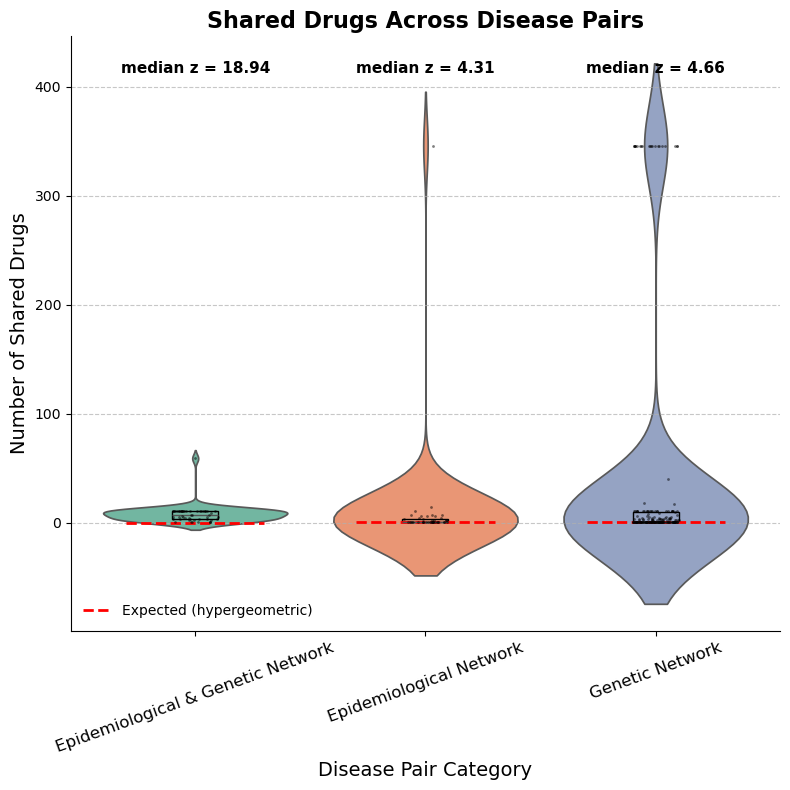

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))

# 1. Define the explicit order of categories
# (This ensures the plot 0,1,2... matches your loop 0,1,2...)
order = sorted(df_plot["category"].unique()) 
# OR, if you want a specific custom order:
# order = ["Stage 1", "Stage 2", "Stage 3", "Stage 4"]

# 2. Pass this 'order' to ALL Seaborn plots
sns.violinplot(
    data=df_plot, x="category", y="shared_drugs",
    inner=None, scale="width", palette="Set2",
    order=order  # <--- Crucial
)

sns.boxplot(
    data=df_plot, x="category", y="shared_drugs",
    width=0.2, showcaps=False,
    boxprops={"facecolor": "none", "edgecolor": "black"},
    showfliers=False, whiskerprops={"linewidth": 0},
    order=order  # <--- Crucial
)

sns.stripplot(
    data=df_plot, x="category", y="shared_drugs",
    color="black", size=2, alpha=0.5, jitter=True,
    order=order  # <--- Crucial
)

ax = plt.gca()

# 3. Iterate through the SAME 'order' list to place text/lines
for i, cat in enumerate(order):
    # Fetch the specific row from summary for this category
    # (Assumes 'category' is a column in summary. If it's the index, use summary.loc[cat])
    row = summary[summary["category"] == cat].iloc[0]
    
    # Add Text
    ax.text(
        i,
        ax.get_ylim()[1] * 0.95,
        f"median z = {row['median_z']:.2f}",
        ha="center", va="top",
        fontsize=11, fontweight="bold"
    )
    
    # Add Red Line
    ax.hlines(
        y=row["median_expected"],
        xmin=i - 0.3,
        xmax=i + 0.3,
        colors="red",
        linestyles="dashed",
        linewidth=2,
        label="Expected (hypergeometric)" if i == 0 else ""
    )

# Formatting
plt.xticks(rotation=20, fontsize=12)
plt.xlabel("Disease Pair Category", fontsize=14)
plt.ylabel("Number of Shared Drugs", fontsize=14)
plt.title("Shared Drugs Across Disease Pairs", fontsize=16, weight="bold")

plt.legend(frameon=False)
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

# Save
plt.savefig("Figures/Fig5C_shareddrugs_disease_pairs_v2026_official.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Figures/Fig5C_shareddrugs_disease_pairs_v2026_official.svg", format="svg", dpi=300, bbox_inches="tight")

plt.show()

In [57]:

rows = []

# -----------------------------
# 1. Pair-level data
# -----------------------------
for cat in order:
    subset = df_plot[df_plot["category"] == cat]
    
    for idx, row in subset.iterrows():
        rows.append({
            "Category": cat,
            "Disease_A": row.get("Disease_A", None),
            "Disease_B": row.get("Disease_B", None),
            "Observed_Shared_Drugs": row["shared_drugs"],
            "Expected_Shared_Drugs": row.get("expected_shared", None),
            "Z_score": row.get("z_score", None),
            "Median_Z_for_Category": None,
            "Median_Expected_for_Category": None,
            "metadata": None
        })

df_pairs = pd.DataFrame(rows)

# -----------------------------
# 2. Add summary statistics used in figure annotations
# -----------------------------
summary_rows = []

for cat in order:
    row = summary[summary["category"] == cat].iloc[0]
    
    summary_rows.append({
        "Category": cat,
        "Disease_A": None,
        "Disease_B": None,
        "Observed_Shared_Drugs": None,
        "Expected_Shared_Drugs": None,
        "Z_score": None,
        "Median_Z_for_Category": row["median_z"],
        "Median_Expected_for_Category": row["median_expected"],
        "metadata": "Category-level summary used for figure annotation"
    })

df_summary = pd.DataFrame(summary_rows)

# -----------------------------
# 3. Metadata rows
# -----------------------------
metadata_entries = [
    "Violin plot: scale='width', inner=None",
    "Boxplot: showfliers=False, width=0.2",
    "Stripplot: jitter=True, alpha=0.5",
    "Red dashed line = median_expected (hypergeometric mean)",
    "Text annotation = median_z per category",
    "Category order locked via explicit 'order' list",
    f"Total N pairs: {len(df_plot)}"
]

metadata_df = pd.DataFrame({
    "Category": [None]*len(metadata_entries),
    "Disease_A": [None]*len(metadata_entries),
    "Disease_B": [None]*len(metadata_entries),
    "Observed_Shared_Drugs": [None]*len(metadata_entries),
    "Expected_Shared_Drugs": [None]*len(metadata_entries),
    "Z_score": [None]*len(metadata_entries),
    "Median_Z_for_Category": [None]*len(metadata_entries),
    "Median_Expected_for_Category": [None]*len(metadata_entries),
    "metadata": metadata_entries
})

# -----------------------------
# 4. Combine everything
# -----------------------------
source_df = pd.concat(
    [df_pairs, df_summary, metadata_df],
    ignore_index=True
)

# Deterministic ordering
source_df = source_df.sort_values(
    ["Category", "Disease_A", "Disease_B"],
    na_position="last"
).reset_index(drop=True)

excel_path = "output/SourceData.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a",if_sheet_exists="replace") as writer:
    source_df.to_excel(writer, sheet_name="Fig5C", index=False)

print(f"Saved to {excel_path}")

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_37892/3849695474.py:74: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  source_df = pd.concat(


Saved to output/SourceData.xlsx


In [58]:
#Let's create a table with the disease pairs and their share drugs
disease_drugs_shared_df = pd.DataFrame()

disA_list = []
disB_list = []
epidemiological_status_list = []
genetic_status_list = []
shared_drug_list = []

tot_disease_with_drugs_pairs_list = genetic_epidemiological_disease_pairs_with_drugs + genetic_disease_pairs_with_drugs + epidemiological_disease_pairs_with_drugs
for dispair in tot_disease_with_drugs_pairs_list:
    disA = dispair[0]
    disB = dispair[1]
    disA_list.append(disA)
    disB_list.append(disB)
    if (disA,disB) in epidemiological_disease_pairs_with_drugs or (disB,disA) in epidemiological_disease_pairs_with_drugs:
        epidemiological_status_list.append(True)
    else:
        epidemiological_status_list.append(False)
    if (disA,disB) in genetic_disease_pairs_with_drugs or (disB,disA) in genetic_disease_pairs_with_drugs:
        genetic_status_list.append(True)
    else:
        genetic_status_list.append(False)
    shared_drugs_set = set(disease_approveddrugs_dict[disA])&set(disease_approveddrugs_dict[disB])
    shared_drug_list.append(str(shared_drugs_set))

disease_drugs_shared_df["Disease A"] = disA_list
disease_drugs_shared_df["Disease B"] = disB_list
disease_drugs_shared_df["Epidemiological network"] = epidemiological_status_list
disease_drugs_shared_df["Genetic network"] = genetic_status_list
disease_drugs_shared_df["Shared drugs"] = shared_drug_list

disease_drugs_shared_df.head()



,Disease A,Disease B,Epidemiological network,Genetic network,Shared drugs
0,F13,F15,False,False,"{'Molindone', 'Quetiapine', 'Prochlorperazine'..."
1,F14,F15,False,False,"{'Molindone', 'Quetiapine', 'Prochlorperazine'..."
2,F10,F12,False,False,"{'Molindone', 'Quetiapine', 'Prochlorperazine'..."
3,F17,F20,False,False,"{'Quetiapine', 'Olanzapine', 'Aripiprazole', '..."
4,F10,F17,False,False,"{'Molindone', 'Quetiapine', 'Prochlorperazine'..."


In [59]:
disease_drugs_shared_df.to_csv("output/Supp_Tab4_disease_drugs_shared_df_2026_official.csv")

In [60]:
#Let's import the dictionary with the approved drugs-genes annotations from DrugBank

#Let's import the diseases
with open('output/allsources_icd_gene_dict_unified_v2026_official.pickle', 'rb') as handle:
    icd_genes_dict = pk.load(handle)

In [61]:
genetic_background = set([x for xs in list(icd_genes_dict.values()) for x in xs]).union(set([x for xs in list(fda_approved_drug_to_genes_dict.values()) for x in xs]))
len(genetic_background)

12742

In [62]:
#Let's check that the amount of diseases that have approved/indicated drugs also from a molecular point of view

#First, we need to find the statistically significant disease-drug associations:
drug_intersection_pval_dict = {}
drug_intersection_fdr_dict = {}
drug_intersection_sigfdr_dict = {}

for dis,genelist_A in icd_genes_dict.items():
    for drug,genelist_B in fda_approved_drug_to_genes_dict.items():
        drug_intersection_pval = float(fisher_test(set(genelist_A),set(genelist_B),len(genetic_background)))
        drug_intersection_pval_dict[(dis,drug)] = drug_intersection_pval
        
drug_intersection_adj_pval_list = fdr_adjustment(list(drug_intersection_pval_dict.values()),0.05)
pair_list=list(drug_intersection_pval_dict.keys())
for i in range(len(drug_intersection_adj_pval_list)):
    drug_intersection_fdr_dict[pair_list[i]]=drug_intersection_adj_pval_list[i]

for dis_pair,fdr in drug_intersection_fdr_dict.items():
    if fdr<0.05:
        drug_intersection_sigfdr_dict[dis_pair] = fdr

dis_mol_sig_drug_dict = {}
for dis,genelist_A in icd_genes_dict.items():
    drug_list = []
    for dis_pair in drug_intersection_sigfdr_dict.keys():
        if dis==dis_pair[0]:
            drug_list.append(dis_pair[1])
    if len(drug_list)>0:
        dis_mol_sig_drug_dict[dis] = drug_list
        
print(len(dis_mol_sig_drug_dict))

349


In [87]:
len(fda_approved_drug_to_genes_dict)

2253

In [71]:
disease_drug_mol_df = pd.DataFrame()

dis_list = []
drug_list = []
fdr_list = []
indication_list = []


for dis_drug,fdr in drug_intersection_sigfdr_dict.items():
    dis = dis_drug[0]
    drug = dis_drug[1]
    dis_list.append(dis)
    drug_list.append(drug)
    fdr_list.append(str(fdr))
    try:
        if drug in disease_approveddrugs_dict[dis]:
            indication_list.append(True)
        else:
            indication_list.append(False)
    except:
        indication_list.append(False)


disease_drug_mol_df["ICD"] = dis_list
disease_drug_mol_df["Drug"] = drug_list
disease_drug_mol_df["FDR (molecular overlap)"] = fdr_list
disease_drug_mol_df["Reported indication"] = indication_list

disease_drug_mol_df.head()

,ICD,Drug,FDR (molecular overlap),Reported indication
0,A01,Etanercept,0.008650389044295971,False
1,A02,Ustekinumab,0.019743686428985566,False
2,A02,Tildrakizumab,0.03368777239220022,False
3,A05,Botulinum Toxin Type B,3.3819264920098907e-07,False
4,A15,Cisplatin,0.03624991492224835,False


In [72]:
for icd in disease_approveddrugs_dict.keys():
    ji_overlap = len(set(disease_drug_mol_df[disease_drug_mol_df["ICD"]==icd]["Drug"].tolist()) & set(disease_approveddrugs_dict[icd])) / len(set(disease_approveddrugs_dict[icd]))
    if ji_overlap>0.6:
        if len(set(disease_drug_mol_df[disease_drug_mol_df["ICD"]==icd]["Drug"].tolist()))<100:
            print(icd,ji_overlap)


C45 1.0
E23 1.0
E50 1.0
E55 0.75
F13 0.8181818181818182
F15 0.8181818181818182
F16 0.8181818181818182
F17 0.8181818181818182
F18 0.8181818181818182
F19 0.8181818181818182
F41 0.7333333333333333
F91 1.0
H20 1.0
K83 1.0


In [84]:
len(set(disease_drug_mol_df["ICD"]) & disease_approveddrugs_dict.keys())

163

In [73]:
len(set(disease_drug_mol_df[disease_drug_mol_df["ICD"]=="E55"]["Drug"].tolist()))

11

In [74]:
len(set(disease_approveddrugs_dict["E55"]))

4

In [67]:
set(disease_approveddrugs_dict["E55"]) & set(disease_drug_mol_df[disease_drug_mol_df["ICD"]=="E55"]["Drug"].tolist())

{'Calcidiol', 'Calcitriol', 'Cholecalciferol'}

In [75]:
#Let's import the disease Name
disease_name_consensus_df = pd.read_csv("output/disease_name_consensus_official_names.tsv",sep="\t")

In [76]:
disease_name_consensus_df = disease_name_consensus_df[
    ["ICD", "Disease Name", "PubMed_query_name"]
]

disease_drug_mol_df = disease_drug_mol_df.merge(
    disease_name_consensus_df,
    on="ICD",
    how="left"   # keeps all rows from disease_drug_mol_df
)

disease_drug_mol_df.head()

,ICD,Drug,FDR (molecular overlap),Reported indication,Disease Name,PubMed_query_name
0,A01,Etanercept,0.008650389044295971,False,typhoid and paratyphoid fevers;typhoid fever;p...,typhoid and paratyphoid fevers
1,A02,Ustekinumab,0.019743686428985566,False,other salmonella infections;salmonella gastro-...,salmonella infections
2,A02,Tildrakizumab,0.03368777239220022,False,other salmonella infections;salmonella gastro-...,salmonella infections
3,A05,Botulinum Toxin Type B,3.3819264920098907e-07,False,other bacterial foodborne intoxications;foodbo...,bacterial foodborne intoxications
4,A15,Cisplatin,0.03624991492224835,False,"respiratory tuberculosis, bacteriologically an...","respiratory tuberculosis, bacteriologically an..."


In [77]:
disease_drug_mol_df.to_csv("output/Supp_Tab5_disease_molecular_drugs_df_v2026_official.csv")

In [31]:
disease_drug_mol_df = pd.read_csv("output/Supp_Tab5_disease_molecular_drugs_df_v2026_official.csv")

In [6]:

# 1. Isolate the metadata mappings (ICD -> Disease/Consensus.Name)
icd_map = disease_drug_mol_df[['ICD', 'Disease Name', 'Consensus Name']].drop_duplicates()
all_unique_drugs = disease_drug_mol_df['Drug'].unique()

# 2. Set target size (1/10th)
target_size = len(disease_drug_mol_df) // 10

# 3. Create a helper set of existing strings for "Instant Exclusion"
# We combine ICD and Drug into a single string 'ICD_Drug' for the fastest possible lookup
existing_pairs = set(disease_drug_mol_df['ICD'] + "_" + disease_drug_mol_df['Drug'])

random_samples = []
generated_pairs = set() # To ensure we don't pick the same random pair twice

while len(random_samples) < target_size:
    # Randomly pick an ICD entry and a Drug
    rand_icd_row = icd_map.sample(n=1).iloc[0]
    rand_drug = np.random.choice(all_unique_drugs)
    
    pair_id = f"{rand_icd_row['ICD']}_{rand_drug}"
    
    # CRITICAL CHECK:
    # 1. Does it exist in the original data?
    # 2. Have we already picked it for our random list?
    if (pair_id not in existing_pairs) and (pair_id not in generated_pairs):
        random_samples.append({
            'ICD': rand_icd_row['ICD'],
            'Drug': rand_drug,
            'Disease Name': rand_icd_row['Disease Name'],
            'Consensus Name': rand_icd_row['Consensus Name']
        })
        generated_pairs.add(pair_id)

# 4. Final DataFrame
random_drug_df = pd.DataFrame(random_samples)

# --- Verification Step ---
# This merges the random DF with the original to prove no overlaps exist
overlap_check = pd.merge(random_drug_df, disease_drug_mol_df[['ICD', 'Drug']], 
                         on=['ICD', 'Drug'], how='inner')

print(f"Random pairs generated: {len(random_drug_df)}")
print(f"Number of overlapping pairs found (should be 0): {len(overlap_check)}")

Random pairs generated: 902
Number of overlapping pairs found (should be 0): 0


In [7]:
random_drug_df.to_csv("output/random_molecular_icd_drug_df_official.csv")

In [7]:
random_drug_df = pd.read_csv("output/random_molecular_icd_drug_df_official.csv")

In [20]:


random_drug_df = random_drug_df.merge(
    disease_name_consensus_df,
    on="ICD",
    how="left"   # keeps all rows from disease_drug_mol_df
)

random_drug_df.head()

,Unnamed: 0,ICD,Drug,Consensus Name,Disease Name,PubMed_query_name
0,0,G20,Rabeprazole,parkinson's disease,parkinson's disease,parkinson's disease
1,1,E79,Moclobemide,disorders of purine and pyrimidine metabolism,disorders of purine and pyrimidine metabolism;...,disorders of purine and pyrimidine metabolism
2,2,N05,Remifentanil,minor glomerular abnormality,unspecified nephritic syndrome;minor glomerula...,minor glomerular abnormality
3,3,I48,Technetium Tc-99m tetrofosmin,atrial fibrillation and flutter,atrial fibrillation and flutter;paroxysmal atr...,atrial fibrillation and flutter
4,4,E46,Acetylcysteine,unspecified protein-energy malnutrition,unspecified protein-energy malnutrition,protein-energy malnutrition


In [21]:
random_drug_df.to_csv("output/random_molecular_icd_drug_df_official.csv")

In [32]:
#Let's run PubMed
disease_drug_mol_df = pd.read_csv("output/Supp_Tab5_disease_molecular_drugs_df_v2026_official.csv")
random_drug_df = pd.read_csv("output/random_molecular_icd_drug_df_official.csv")

In [ ]:
import re

from Bio import Entrez
import time

GENERIC_SINGLE_WORDS = {
    "simple", "other", "unspecified", "related", "associated",
    "mixed", "acute", "chronic", "secondary", "primary", "pain",
    "mental", "general", "multiple", "various", "certain", "due"
}

Entrez.email = "yourmail@gmail.com"
Entrez.tool = "drug_project"
def contains_boolean_words(term):
    return bool(re.search(r'\b(and|or|not)\b', term, flags=re.IGNORECASE))

def split_on_boolean_words(term):
    """Split a phrase on AND/OR/NOT, returning only the text chunks."""
    parts = re.split(r'\b(and|or|not)\b', term, flags=re.IGNORECASE)
    chunks = [p.strip() for p in parts
              if not re.match(r'^(and|or|not)$', p.strip(), re.IGNORECASE)]
    return [c for c in chunks if c]

def is_meaningful_fragment(fragment):
    """
    Multi-word fragments are always kept.
    Single-word fragments are kept only if clinically specific
    (i.e. not in the generic stoplist).
    """
    words = fragment.split()
    if len(words) > 1:
        return True
    return words[0].lower() not in GENERIC_SINGLE_WORDS

def build_disease_clause(disease_name):
    if not contains_boolean_words(disease_name):
        # Safe to drop quotes — no boolean words to hijack the query
        # Automatic term mapping gives full MeSH expansion → maximum recall
        return f'{disease_name}[All Fields]'

    # Boolean words present — quotes are mandatory to prevent hijacking
    # Accept that we lose automatic mapping; fragments + OR is the best we can do
    parts = split_on_boolean_words(disease_name)
    meaningful_parts = [p for p in parts if is_meaningful_fragment(p)]
    if not meaningful_parts:
        meaningful_parts = parts

    # Quotes required here to protect each fragment
    clauses = ' OR '.join(f'"{p}"[All Fields]' for p in meaningful_parts)
    return f'({clauses})'

def build_drug_clause(drug_name):
    # Drug names rarely contain boolean words, but check anyway
    if contains_boolean_words(drug_name):
        return f'"{drug_name}"[All Fields]'
    return f'{drug_name}[All Fields]'

def build_pubmed_query(drug_name, disease_name):
    drug_q    = build_drug_clause(drug_name)
    disease_q = build_disease_clause(disease_name)
    return f'({drug_q} AND {disease_q})'

def get_pubmed_count(query):
    handle = Entrez.esearch(db="pubmed", term=query, retmode="xml", retmax=0)
    record = Entrez.read(handle)
    handle.close()
    return int(record["Count"])

# -----------------------------
# Spot-check helper
# -----------------------------
def spot_check(drug_name, disease_name):
    """Print the query and its count for manual verification."""
    query = build_pubmed_query(drug_name, disease_name)
    count = get_pubmed_count(query)
    print(f"Drug   : {drug_name}")
    print(f"Disease: {disease_name}")
    print(f"Query  : {query}")
    print(f"Count  : {count}")
    print()
    return count

# -----------------------------
# Load pairs
# -----------------------------
pairs = set()

with open("disease_pairs_for_pubmed.txt", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split("\t")
        if len(parts) != 2:
            continue
        drug, disease = parts
        pairs.add((drug, disease))

print(f"Loaded {len(pairs)} unique drug-disease pairs")


# -----------------------------
# Main loop
# -----------------------------
drugbank_lit_associations_chem_dict = {}

for idx, (drug, disease) in enumerate(pairs):
    had_boolean = contains_boolean_words(disease)
    try:
        query = build_pubmed_query(drug, disease)
        count = get_pubmed_count(query)
        drugbank_lit_associations_chem_dict[drug, disease] = count
        time.sleep(0.34)

    except Exception as e:
        drugbank_lit_associations_chem_dict[drug, disease] = None

    # Progress report every 100 pairs
    if (idx + 1) % 100 == 0:
        print(f"  Processed {idx + 1}/{len(pairs)} pairs...")

# -----------------------------
# Save
# -----------------------------
with open('drugbank_lit_associations_chem_dict_claude.pickle', 'wb') as handle:
    pk.dump(drugbank_lit_associations_chem_dict, handle, protocol=pk.HIGHEST_PROTOCOL)


In [104]:
with open('output/disease_drug_mol_pubmed.pickle', 'wb') as handle:
    pk.dump(drugbank_lit_associations_chem_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [96]:
with open('output/disease_drug_mol_pubmed.pickle', 'rb') as handle:
    drugbank_lit_associations_chem_dict = pk.load(handle)

In [47]:
with open('output/drugbank_lit_associations_chem_dict_claude.pickle', 'rb') as handle:
    final_drug_dis_pair_pubmed_dict = pk.load(handle)


In [48]:
len(final_drug_dis_pair_pubmed_dict)

149595

In [34]:
drugbank_lit_associations_chem_dict = {}
for i,v in disease_drug_mol_df.iterrows():
    drug_name = v["Drug"]
    disease_name = v["PubMed_query_name"]
    drugbank_lit_associations_chem_dict[drug_name,disease_name] = final_drug_dis_pair_pubmed_dict[drug_name,disease_name]

In [35]:
pubmed_count_list = []
for i,v in disease_drug_mol_df.iterrows():
    drug_name = v["Drug"]
    disease_name = v["PubMed_query_name"]
    pubmed_count = drugbank_lit_associations_chem_dict[drug_name,disease_name]
    pubmed_count_list.append(pubmed_count)

disease_drug_mol_df["PubMed count"] = pubmed_count_list

In [36]:
disease_drug_mol_df.to_csv("output/Supp_Tab5_disease_molecular_drugs_df_v2026_official_Pubmed.csv")

In [37]:
import re

Entrez.email = "yourmail@gmail.com"
Entrez.tool = "drug_project"
# Entrez.api_key = "YOUR_KEY"  # recommended for large runs (10 req/sec vs 1 req/sec)

# -----------------------------
# Constants
# -----------------------------
GENERIC_SINGLE_WORDS = {
    "simple", "other", "unspecified", "related", "associated",
    "mixed", "acute", "chronic", "secondary", "primary", "pain",
    "mental", "general", "multiple", "various", "certain", "due"
}

# -----------------------------
# Core helpers
# -----------------------------
def contains_boolean_words(term):
    return bool(re.search(r'\b(and|or|not)\b', term, flags=re.IGNORECASE))

def split_on_boolean_words(term):
    """Split a phrase on AND/OR/NOT, returning only the text chunks."""
    parts = re.split(r'\b(and|or|not)\b', term, flags=re.IGNORECASE)
    chunks = [p.strip() for p in parts
              if not re.match(r'^(and|or|not)$', p.strip(), re.IGNORECASE)]
    return [c for c in chunks if c]

def is_meaningful_fragment(fragment):
    """
    Multi-word fragments are always kept.
    Single-word fragments are kept only if clinically specific
    (i.e. not in the generic stoplist).
    """
    words = fragment.split()
    if len(words) > 1:
        return True
    return words[0].lower() not in GENERIC_SINGLE_WORDS

# -----------------------------
# Query builders
# -----------------------------
def build_disease_clause(disease_name):
    if not contains_boolean_words(disease_name):
        # Unquoted, no field tag → automatic term mapping, mirrors web interface
        return f'{disease_name}'

    # Boolean words present: split into fragments and OR them explicitly.
    # This prevents PubMed from parsing the raw 'and'/'or' words in the disease
    # string as uncontrolled Boolean operators with wrong precedence.
    # Each fragment is still unquoted → automatic term mapping applies per fragment.
    parts = split_on_boolean_words(disease_name)
    meaningful_parts = [p for p in parts if is_meaningful_fragment(p)]
    if not meaningful_parts:
        meaningful_parts = parts

    clauses = ' OR '.join(f'{p}' for p in meaningful_parts)
    return f'({clauses})'
def build_drug_clause(drug_name):
    # Unquoted, no field tag → automatic term mapping
    return f'{drug_name}'

def build_pubmed_query(drug_name, disease_name):
    drug_q    = build_drug_clause(drug_name)
    disease_q = build_disease_clause(disease_name)
    return f'({drug_q} AND {disease_q})'

# -----------------------------
# PubMed fetch
# -----------------------------
def get_pubmed_count(query):
    handle = Entrez.esearch(db="pubmed", term=query, retmode="xml", retmax=0)
    record = Entrez.read(handle)
    handle.close()
    return int(record["Count"])



In [39]:
random_drugbank_lit_associations_chem_dict = {}
for i,v in random_drug_df.iterrows():
    drug_name = v["Drug"]
    disease_name = v["PubMed_query_name"]
    if str(disease_name)!="nan":
        try:
            random_drugbank_lit_associations_chem_dict[drug_name,disease_name]= final_drug_dis_pair_pubmed_dict[drug_name,disease_name]
        except KeyError:
            query = build_pubmed_query(drug_name, disease_name)
            count = get_pubmed_count(query)
            random_drugbank_lit_associations_chem_dict[drug_name,disease_name] = count

pubmed_count_list = []
for i,v in random_drug_df.iterrows():
    drug_name = v["Drug"]
    disease_name = v["PubMed_query_name"]
    if str(disease_name)=="nan":
        pubmed_count_list.append(0)
    else:
        pubmed_count = random_drugbank_lit_associations_chem_dict[drug_name,disease_name]
        pubmed_count_list.append(pubmed_count)

random_drug_df["PubMed count"] = pubmed_count_list

In [40]:

random_drug_df.to_csv("output/random_molecular_icd_drug_df_official_Pubmed.csv")

In [38]:
#Let's import the PubMed count prediction
drug_pubmed_df = pd.read_csv("output/Supp_Tab5_disease_molecular_drugs_df_v2026_official_Pubmed.csv")

In [54]:
#Let's import the random results from the PubMed count
random_molecular_icd_drug_df_PubMed = pd.read_csv("output/random_molecular_icd_drug_df_official_Pubmed.csv")

In [55]:
drug_pubmed_df.dropna(inplace=True)

num_diseases_list = []
num_papers_list = []

for i,v in drug_pubmed_df.iterrows():
    num_diseases_list.append(len(v["Disease Name"].split(";")))
    num_papers_list.append(int(v['PubMed count']))

pearson_corr, pearson_p = pearsonr(num_diseases_list, num_papers_list)
spearman_corr, spearman_p = spearmanr(num_diseases_list, num_papers_list)

print(f"Pearson correlation: r = {pearson_corr:.3f}, p = {pearson_p:.3e}")
print(f"Spearman correlation: ρ = {spearman_corr:.3f}, p = {spearman_p:.3e}")

Pearson correlation: r = 0.012, p = 2.599e-01
Spearman correlation: ρ = 0.043, p = 5.934e-05


Pearson correlation: r = 0.133, p = 7.136e-01
Spearman correlation: ρ = 0.430, p = 2.145e-01


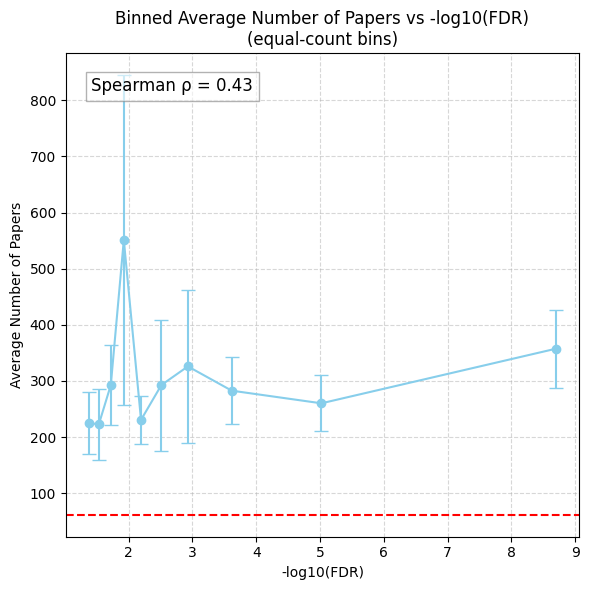

In [56]:

# --- Prepare data ---
pubmed_count = []
fdr_list = []

for idx, row in drug_pubmed_df.iterrows():
    fdr_list.append(row['FDR (molecular overlap)'])
    pubmed_count.append(row['PubMed count'])

# Transform FDR: -log10(FDR)
fdr_array = np.array(fdr_list, dtype=float)
fdr_array[fdr_array <= 0] = np.min(fdr_array[fdr_array > 0]) * 0.5  # avoid log10(0)
fdr_log = -np.log10(fdr_array)

pubmed_count_array = np.array(pubmed_count, dtype=float)

# --- Bin the data with equal counts ---
num_bins = 10
bins = np.quantile(fdr_log, np.linspace(0, 1, num_bins+1))
bin_centers = []
binned_means = []
binned_se = []

for i in range(num_bins):
    if i == num_bins - 1:
        mask = (fdr_log >= bins[i]) & (fdr_log <= bins[i+1])
    else:
        mask = (fdr_log >= bins[i]) & (fdr_log < bins[i+1])
        
    #mask = (fdr_log >= bins[i]) & (fdr_log < bins[i+1])
    values_in_bin = pubmed_count_array[mask]
    if len(values_in_bin) > 0:
        bin_centers.append(np.mean(fdr_log[mask]))
        mean_val = np.mean(values_in_bin)
        se_val = np.std(values_in_bin, ddof=1) / np.sqrt(len(values_in_bin))
    else:
        bin_centers.append(np.nan)
        mean_val = np.nan
        se_val = np.nan
    binned_means.append(mean_val)
    binned_se.append(se_val)

bin_centers = np.array(bin_centers)
binned_means = np.array(binned_means)

# --- Compute correlations ---
valid_mask = ~np.isnan(bin_centers) & ~np.isnan(binned_means)
pearson_corr, pearson_p = pearsonr(bin_centers[valid_mask], binned_means[valid_mask])
spearman_corr, spearman_p = spearmanr(bin_centers[valid_mask], binned_means[valid_mask])

print(f"Pearson correlation: r = {pearson_corr:.3f}, p = {pearson_p:.3e}")
print(f"Spearman correlation: ρ = {spearman_corr:.3f}, p = {spearman_p:.3e}")

# --- Plot binned means with error bars ---
plt.figure(figsize=(6,6))
plt.errorbar(bin_centers, binned_means, yerr=binned_se, fmt='o-', 
             color='skyblue', capsize=5, label='Binned Means')
plt.axhline(np.mean(random_molecular_icd_drug_df_PubMed['PubMed count']), color='red', linestyle='--', label='Random Mean')
plt.xlabel('-log10(FDR)')
plt.ylabel('Average Number of Papers')
plt.title('Binned Average Number of Papers vs -log10(FDR)\n(equal-count bins)')
plt.grid(True, linestyle='--', alpha=0.5)

# Annotate correlation
plt.text(0.05, 0.95, f"Spearman ρ = {spearman_corr:.2f}", 
         transform=plt.gca().transAxes, fontsize=12, va='top', ha='left',
         bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray'))

plt.tight_layout()
#plt.savefig("Figures/Fig5C_PubMed_Mol_Corr_v3_2026_official.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig("Figures/Fig5C_PubMed_Mol_Corr_v3_2026_official.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
import pandas as pd
import numpy as np
import os

# Ensure output directory exists
os.makedirs("output", exist_ok=True)

# --- Save binned data ---
bin_counts = []

for i in range(num_bins):
    mask = (fdr_log >= bins[i]) & (fdr_log < bins[i+1])
    bin_counts.append(np.sum(mask))

df_bins = pd.DataFrame({
    "bin_center_-log10FDR": bin_centers,
    "mean_pubmed_count": binned_means,
    "standard_error": binned_se,
    "n_points": bin_counts
})

# --- Save correlation results ---
df_corr = pd.DataFrame({
    "metric": ["Pearson_r", "Pearson_p", "Spearman_rho", "Spearman_p"],
    "value": [pearson_corr, pearson_p, spearman_corr, spearman_p]
})

# --- Write to Excel ---
excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    # Write binned data
    df_bins.to_excel(writer, sheet_name="Fig5D_bins", index=False, startrow=0)

    # Write correlations below
    df_corr.to_excel(
        writer,
        sheet_name="Fig5D_correlation",
        index=False,
        startrow=len(df_bins) + 3
    )

print(f"Saved results to {excel_path}")

Saved results to output/SourceData.xlsx


In [85]:
#Let's check that the amount of diseases that have approved/indicated drugs also from a molecular point of view

disease_approveddrugs_shared_mol_pval_dict = {}
disease_approveddrugs_shared_mol_fdr_dict = {}
disease_approveddrugs_shared_mol_sigfdr_dict = {}

for disA,druglist in disease_approveddrugs_dict.items():
    try:
        drug_overlap_pval = float(fisher_test(set(druglist),set(dis_mol_sig_drug_dict[disA]),len(tot_drug_list)))
        disease_approveddrugs_shared_mol_pval_dict[disA]=drug_overlap_pval
    except:
        pass
    
drug_intersection_adj_pval_list = fdr_adjustment(list(disease_approveddrugs_shared_mol_pval_dict.values()),0.05)
pair_list=list(disease_approveddrugs_shared_mol_pval_dict.keys())
for i in range(len(drug_intersection_adj_pval_list)):
    disease_approveddrugs_shared_mol_fdr_dict[pair_list[i]]=drug_intersection_adj_pval_list[i]

for dis_pair,fdr in disease_approveddrugs_shared_mol_fdr_dict.items():
    if fdr<0.05:
        disease_approveddrugs_shared_mol_sigfdr_dict[dis_pair] = fdr


print(len(disease_approveddrugs_shared_mol_sigfdr_dict))

34


In [108]:
#Let's check that the amount of diseases that have approved/indicated drugs also from a molecular point of view

disease_approveddrugs_shared_mol_oneshared_dict = []

for disA,druglist in disease_approveddrugs_dict.items():
    try:
        drug_overlap = len(set(druglist)&set(dis_mol_sig_drug_dict[disA]))
        if drug_overlap>0:
            disease_approveddrugs_shared_mol_oneshared_dict.append(disA)
    except:
        pass

print(len(disease_approveddrugs_shared_mol_oneshared_dict))

60


In [ ]:
#Let's do the same for the trajectories

In [68]:
with open('output/male_trajectories_dict_filtered_unique_agglomerated_genes_v2026_official.pickle', 'rb') as handle:
    male_trajectories_dict_filtered_unique_agglomerated_genes = pk.load(handle)
with open('output/female_trajectories_dict_filtered_unique_agglomerated_genes_v2026_official.pickle', 'rb') as handle:
    female_trajectories_dict_filtered_unique_agglomerated_genes = pk.load(handle)


In [69]:
#Let's check that the amount of diseases that have approved/indicated drugs also from a molecular point of view

#First, we need to find the statistically significant disease-drug associations:
male_trajectories_dict_filtered_unique_drug_intersection_pval_dict = {}
male_trajectories_dict_filtered_unique_drug_intersection_fdr_dict = {}
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_dict = {}

for dis,genelist_A in male_trajectories_dict_filtered_unique_agglomerated_genes.items():
    for drug,genelist_B in fda_approved_drug_to_genes_dict.items():
        drug_intersection_pval = float(fisher_test(set(genelist_A),set(genelist_B),len(genetic_background)))
        male_trajectories_dict_filtered_unique_drug_intersection_pval_dict[(dis,drug)] = drug_intersection_pval
        
drug_intersection_adj_pval_list = fdr_adjustment(list(male_trajectories_dict_filtered_unique_drug_intersection_pval_dict.values()),0.05)
pair_list=list(male_trajectories_dict_filtered_unique_drug_intersection_pval_dict.keys())
for i in range(len(drug_intersection_adj_pval_list)):
    male_trajectories_dict_filtered_unique_drug_intersection_fdr_dict[pair_list[i]]=drug_intersection_adj_pval_list[i]

for dis_pair,fdr in male_trajectories_dict_filtered_unique_drug_intersection_fdr_dict.items():
    if fdr<0.05:
        male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_dict[dis_pair] = fdr

male_trajectories_dict_filtered_unique_mol_sig_drug_dict = {}
for dis,genelist_A in male_trajectories_dict_filtered_unique_agglomerated_genes.items():
    drug_list = []
    for dis_pair in male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_dict.keys():
        if dis==dis_pair[0]:
            drug_list.append(dis_pair[1])
    if len(drug_list)>0:
        male_trajectories_dict_filtered_unique_mol_sig_drug_dict[dis] = drug_list
        
print(len(male_trajectories_dict_filtered_unique_mol_sig_drug_dict))

275


In [70]:
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df = pd.DataFrame()

trj_list = []
dis_list = []
drug_list = []
fdr_list = []


for trj_drug,fdr in male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_dict.items():
    trj = trj_drug[0]
    drug = trj_drug[1]
    dislist = male_trajectories_dict_filtered_unique[trj]
    trj_list.append(trj)
    dis_list.append(str(dislist))
    drug_list.append(drug)
    fdr_list.append(str(fdr))


male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Trajectory"]=trj_list
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Disease list"]=dis_list
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Drug"]=drug_list
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["FDR"]=fdr_list

male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Trajectory"] = male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Trajectory"].astype(str)

male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.to_csv("output/male_trj_mol_drug_v2026_official.csv")



In [43]:
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df = pd.read_csv("output/male_trj_mol_drug_v2026_official.csv",index_col=0)

In [42]:

male_dis_name_list = []
for i,v in male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.iterrows():
    dis_list = eval(v["Disease list"])
    dis_name_list = []
    for dis in dis_list:
        dis_name_list.append(disease_name_consensus_df[disease_name_consensus_df["ICD"]==dis]["PubMed_query_name"].values[0])
    male_dis_name_list.append(dis_name_list)


male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Disease Consensus Name List"] = male_dis_name_list
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.head()

,Trajectory,Disease list,Drug,FDR,Disease Consensus Name List
0,2,"['A04', 'A08', 'F50']",Amphetamine,0.002535,"[bacterial intestinal infections, viral and sp..."
1,2,"['A04', 'A08', 'F50']",Phentermine,0.018619,"[bacterial intestinal infections, viral and sp..."
2,2,"['A04', 'A08', 'F50']",Citalopram,0.043118,"[bacterial intestinal infections, viral and sp..."
3,2,"['A04', 'A08', 'F50']",Venlafaxine,0.026089,"[bacterial intestinal infections, viral and sp..."
4,2,"['A04', 'A08', 'F50']",Atomoxetine,0.015127,"[bacterial intestinal infections, viral and sp..."


In [43]:
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.to_csv("output/male_trj_mol_drug_v2026_official.csv")

In [248]:
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df = pd.read_csv("output/male_trj_mol_drug_v2026_official.csv",index_col=0)

In [48]:
male_trajectories_df_map = male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df[['Trajectory', 'Disease list', 'Disease Consensus Name List', 'Drug']].drop_duplicates()

all_unique_drugs = male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df['Drug'].unique()

# 2. Set target size (1/10th)
target_size = len(male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df) // 10

# 3. Create a helper set of existing strings for "Instant Exclusion"
# We combine Trajectory and Drug into a single string 'Trajectory_Drug' for the fastest possible lookup
existing_pairs = set(male_trajectories_df_map['Trajectory'] + "_" + male_trajectories_df_map['Drug'])
random_samples = []
generated_pairs = set() # To ensure we don't pick the same random pair twice

while len(random_samples) < target_size:
    # Randomly pick a Trj entry and a Drug
    rand_traj_row = male_trajectories_df_map.sample(n=1).iloc[0]
    rand_drug = np.random.choice(all_unique_drugs)
    
    pair_id = f"{rand_traj_row['Trajectory']}_{rand_drug}"
    
    # CRITICAL CHECK:
    # 1. Does it exist in the original data?
    # 2. Have we already picked it for our random list?
    if (pair_id not in existing_pairs) and (pair_id not in generated_pairs):
        random_samples.append({
            'Trajectory': rand_traj_row['Trajectory'],
            'Drug': rand_drug,
            'Disease list': rand_traj_row['Disease list'],
            'Disease Consensus Name List': rand_traj_row['Disease Consensus Name List']
        })
        generated_pairs.add(pair_id)

# 4. Final DataFrame
random_drug_df = pd.DataFrame(random_samples)

# --- Verification Step ---
# This merges the random DF with the original to prove no overlaps exist
overlap_check = pd.merge(random_drug_df, male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df[['Trajectory', 'Drug']], 
                         on=['Trajectory', 'Drug'], how='inner')

print(f"Random pairs generated: {len(random_drug_df)}")
print(f"Number of overlapping pairs found (should be 0): {len(overlap_check)}")

random_drug_df.to_csv("output/random_male_trj_mol_drug_v2026_official.csv")

Random pairs generated: 1972
Number of overlapping pairs found (should be 0): 0


In [54]:
#Let's run pubmed 
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df = pd.read_csv("output/male_trj_mol_drug_v2026_official.csv",index_col=0)
random_male_drug_df = pd.read_csv("output/random_male_trj_mol_drug_v2026_official.csv",index_col=0)


In [55]:
disease_pair_to_pubmed_count_dict = []
for i,v in male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.iterrows():
    dis_list = eval(v["Disease Consensus Name List"])
    drug = v["Drug"]
    count_list = []
    for dis in dis_list:
        if (drug,dis) not in drugbank_lit_associations_chem_dict:
            disease_pair_to_pubmed_count_dict.append((drug,dis))

print(len(set(disease_pair_to_pubmed_count_dict)))

77406


In [58]:
ordered_count_list = []
count_avg_list = []
for i,v in male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.iterrows():
    dis_list = eval(v["Disease Consensus Name List"])
    drug = v["Drug"]
    count_list = []
    for dis in dis_list:
        try:
            count_list.append(final_drug_dis_pair_pubmed_dict[drug,dis])
        except:
            try:  
                query = build_pubmed_query(drug, dis)
                count = get_pubmed_count(query)
                count_list.append(count)
                time.sleep(0.3)
            except Exception as e:
                count_list.append(0)
    count_list_cl = [count for count in count_list if str(count)!="nan" and count!=None]
    if len(count_list_cl)==0:
        count_list_cl = [0]
    ordered_count_list.append(count_list_cl)
    count_avg_list.append(sum(count_list_cl)/len(count_list_cl))


male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["PubMed count"] = ordered_count_list
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["PubMed count avg"] = count_avg_list

In [59]:
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.to_csv("output/male_trj_mol_drug_v2026_official_PubMed.csv")

In [45]:
male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df = pd.read_csv("output/male_trj_mol_drug_v2026_official_PubMed.csv",index_col=0)

In [60]:
ordered_count_list = []
count_avg_list = []
for i,v in random_male_drug_df.iterrows():
    dis_list = eval(v["Disease Consensus Name List"])
    drug = v["Drug"]
    count_list = []
    for dis in dis_list:
        try:
            count_list.append(final_drug_dis_pair_pubmed_dict[drug,dis])
        except:
            try:        
                query = build_pubmed_query(drug, dis)
                count = get_pubmed_count(query)
                count_list.append(count)
                time.sleep(0.3)
            except Exception as e:
                count_list.append(0)
    count_list_cl = [count for count in count_list if str(count)!="nan" and count!=None]
    if len(count_list_cl)==0:
        count_list_cl = [0]
    ordered_count_list.append(count_list_cl)
    count_avg_list.append(sum(count_list_cl)/len(count_list_cl))


random_male_drug_df["PubMed count"] = ordered_count_list
random_male_drug_df["PubMed count avg"] = count_avg_list


In [61]:

random_male_drug_df.to_csv("output/random_male_trj_mol_drug_v2026_official_PubMed.csv")

In [76]:
#Let's check that the amount of diseases that have approved/indicated drugs also from a molecular point of view

#First, we need to find the statistically significant disease-drug associations:
female_trajectories_dict_filtered_unique_drug_intersection_pval_dict = {}
female_trajectories_dict_filtered_unique_drug_intersection_fdr_dict = {}
female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_dict = {}

for dis,genelist_A in female_trajectories_dict_filtered_unique_agglomerated_genes.items():
    for drug,genelist_B in fda_approved_drug_to_genes_dict.items():
        drug_intersection_pval = float(fisher_test(set(genelist_A),set(genelist_B),len(genetic_background)))
        female_trajectories_dict_filtered_unique_drug_intersection_pval_dict[(dis,drug)] = drug_intersection_pval
        
drug_intersection_adj_pval_list = fdr_adjustment(list(female_trajectories_dict_filtered_unique_drug_intersection_pval_dict.values()),0.05)
pair_list=list(female_trajectories_dict_filtered_unique_drug_intersection_pval_dict.keys())
for i in range(len(drug_intersection_adj_pval_list)):
    female_trajectories_dict_filtered_unique_drug_intersection_fdr_dict[pair_list[i]]=drug_intersection_adj_pval_list[i]

for dis_pair,fdr in female_trajectories_dict_filtered_unique_drug_intersection_fdr_dict.items():
    if fdr<0.05:
        female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_dict[dis_pair] = fdr

female_trajectories_dict_filtered_unique_mol_sig_drug_dict = {}
for dis,genelist_A in female_trajectories_dict_filtered_unique_agglomerated_genes.items():
    drug_list = []
    for dis_pair in female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_dict.keys():
        if dis==dis_pair[0]:
            drug_list.append(dis_pair[1])
    if len(drug_list)>0:
        female_trajectories_dict_filtered_unique_mol_sig_drug_dict[dis] = drug_list
        
print(len(female_trajectories_dict_filtered_unique_mol_sig_drug_dict))

261


In [77]:
female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df = pd.DataFrame()

trj_list = []
dis_list = []
drug_list = []
fdr_list = []


for trj_drug,fdr in female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_dict.items():
    trj = trj_drug[0]
    drug = trj_drug[1]
    dislist = female_trajectories_dict_filtered_unique[trj]
    trj_list.append(trj)
    dis_list.append(str(dislist))
    drug_list.append(drug)
    fdr_list.append(str(fdr))


female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Trajectory"]=trj_list
female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Disease list"]=dis_list
female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Drug"]=drug_list
female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["FDR"]=fdr_list
female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Trajectory"] = female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Trajectory"].astype(str)


female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.to_csv("output/female_trj_mol_drug_v2026_official.csv")



In [52]:
female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.head()

female_dis_name_list = []
for i,v in female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.iterrows():
    dis_list = eval(v["Disease list"])
    dis_name_list = []
    for dis in dis_list:
        dis_name_list.append(disease_name_consensus_df[disease_name_consensus_df["ICD"]==dis]["PubMed_query_name"].values[0])
    female_dis_name_list.append(dis_name_list)


female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Disease Consensus Name List"] = female_dis_name_list
female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.head()
female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.to_csv("output/female_trj_mol_drug_v2026_official.csv")

In [54]:
female_trajectories_df_map = female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df[['Trajectory', 'Disease list', 'Disease Consensus Name List', 'Drug']].drop_duplicates()

all_unique_drugs = female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df['Drug'].unique()

# 2. Set target size (1/10th)
target_size = len(female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df) // 10

# 3. Create a helper set of existing strings for "Instant Exclusion"
# We combine Trajectory and Drug into a single string 'Trajectory_Drug' for the fastest possible lookup
existing_pairs = set(female_trajectories_df_map['Trajectory'] + "_" + female_trajectories_df_map['Drug'])
random_samples = []
generated_pairs = set() # To ensure we don't pick the same random pair twice

while len(random_samples) < target_size:
    # Randomly pick a Trj entry and a Drug
    rand_traj_row = female_trajectories_df_map.sample(n=1).iloc[0]
    rand_drug = np.random.choice(all_unique_drugs)
    
    pair_id = f"{rand_traj_row['Trajectory']}_{rand_drug}"
    
    # CRITICAL CHECK:
    # 1. Does it exist in the original data?
    # 2. Have we already picked it for our random list?
    if (pair_id not in existing_pairs) and (pair_id not in generated_pairs):
        random_samples.append({
            'Trajectory': rand_traj_row['Trajectory'],
            'Drug': rand_drug,
            'Disease list': rand_traj_row['Disease list'],
            'Disease Consensus Name List': rand_traj_row['Disease Consensus Name List']
        })
        generated_pairs.add(pair_id)

# 4. Final DataFrame
random_drug_df = pd.DataFrame(random_samples)

# --- Verification Step ---
# This merges the random DF with the original to prove no overlaps exist
overlap_check = pd.merge(random_drug_df, female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df[['Trajectory', 'Drug']], 
                         on=['Trajectory', 'Drug'], how='inner')

print(f"Random pairs generated: {len(random_drug_df)}")
print(f"Number of overlapping pairs found (should be 0): {len(overlap_check)}")

Random pairs generated: 1791
Number of overlapping pairs found (should be 0): 0


In [55]:

random_drug_df.to_csv("output/random_female_trj_mol_drug_v2026_official.csv")

In [62]:

#Let's run pubmed 
female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df = pd.read_csv("output/female_trj_mol_drug_v2026_official.csv",index_col=0)
random_female_drug_df = pd.read_csv("output/random_female_trj_mol_drug_v2026_official.csv",index_col=0)


In [63]:
ordered_count_list = []
count_avg_list = []
for i,v in female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.iterrows():
    dis_list = eval(v["Disease Consensus Name List"])
    drug = v["Drug"]
    count_list = []
    for dis in dis_list:
        try:
            count_list.append(final_drug_dis_pair_pubmed_dict[drug,dis])
        except:
            try:    
                query = build_pubmed_query(drug, dis)
                count = get_pubmed_count(query)
                count_list.append(count)
                time.sleep(0.3)
            except Exception as e:
                count_list.append(0)
    count_list_cl = [count for count in count_list if str(count)!="nan" and count!=None]
    if len(count_list_cl)==0:
        count_list_cl = [0]
    ordered_count_list.append(count_list_cl)
    count_avg_list.append(sum(count_list_cl)/len(count_list_cl))


female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["PubMed count"] = ordered_count_list
female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["PubMed count avg"] = count_avg_list

In [64]:
female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.to_csv("output/female_trj_mol_drug_v2026_official_PubMed.csv")

In [65]:
ordered_count_list = []
count_avg_list = []
for i,v in random_female_drug_df.iterrows():
    dis_list = eval(v["Disease Consensus Name List"])
    drug = v["Drug"]
    count_list = []
    for dis in dis_list:
        try:
            count_list.append(final_drug_dis_pair_pubmed_dict[drug,dis])
        except:
            try:    
                query = build_pubmed_query(drug, dis)
                count = get_pubmed_count(query)
                count_list.append(count)
                time.sleep(0.3)
            except Exception as e:
                count_list.append(0)
    count_list_cl = [count for count in count_list if str(count)!="nan" and count!=None]
    if len(count_list_cl)==0:
        count_list_cl = [0]
    ordered_count_list.append(count_list_cl)
    count_avg_list.append(sum(count_list_cl)/len(count_list_cl))


random_female_drug_df["PubMed count"] = ordered_count_list
random_female_drug_df["PubMed count avg"] = count_avg_list

In [66]:

random_female_drug_df.to_csv("output/random_female_trj_mol_drug_v2026_officialPubMed.csv")

In [168]:
rd_dis_pair = []
for i,v in random_female_drug_df.iterrows():
    drug = v["Drug"]
    dis_list = eval(v["Disease Consensus Name List"])
    for dis in dis_list:
        rd_dis_pair.append((drug,dis))

for i,v in random_male_drug_df.iterrows():
    drug = v["Drug"]
    dis_list = eval(v["Disease Consensus Name List"])
    for dis in dis_list:
        rd_dis_pair.append((drug,dis))

tot_dis_pair = set(rd_dis_pair).union(set(final_drug_dis_pair_pubmed_dict.keys()))

In [169]:
with open("output/disease_pairs_for_pubmed.txt", "w", encoding="utf-8") as f:
    for el in set(tot_dis_pair):
        drug = el[0]
        disease = el[1]
        f.write(f"{drug}\t{disease}\n")

In [73]:
male_trajectories_dict_filtered_unique_with_drugs_dict_explicit = {}

for trj,disset in male_trajectories_dict_filtered_unique_with_drugs_dict.items():
    drug_list = []
    for dis in disset:
        drug_list.extend(disease_approveddrugs_dict[dis])
    male_trajectories_dict_filtered_unique_with_drugs_dict_explicit[trj] = set(drug_list)


female_trajectories_dict_filtered_unique_with_drugs_dict_explicit = {}

for trj,disset in female_trajectories_dict_filtered_unique_with_drugs_dict.items():
    drug_list = []
    for dis in disset:
        drug_list.extend(disease_approveddrugs_dict[dis])
    female_trajectories_dict_filtered_unique_with_drugs_dict_explicit[trj] = set(drug_list)


In [87]:
#Let's check that the amount of diseases that have approved/indicated drugs also from a molecular point of view

male_approveddrugs_shared_mol_pval_dict = {}
male_approveddrugs_shared_mol_fdr_dict = {}
male_approveddrugs_shared_mol_sigfdr_dict = {}

for disA,druglist in male_trajectories_dict_filtered_unique_with_drugs_dict_explicit.items():
    try:
        drug_overlap_pval = float(fisher_test(set(druglist),set(male_trajectories_dict_filtered_unique_mol_sig_drug_dict[disA]),len(tot_drug_list)))
        male_approveddrugs_shared_mol_pval_dict[disA]=drug_overlap_pval
    except:
        pass
    
drug_intersection_adj_pval_list = fdr_adjustment(list(male_approveddrugs_shared_mol_pval_dict.values()),0.05)
pair_list=list(male_approveddrugs_shared_mol_pval_dict.keys())
for i in range(len(drug_intersection_adj_pval_list)):
    male_approveddrugs_shared_mol_fdr_dict[pair_list[i]]=drug_intersection_adj_pval_list[i]

for dis_pair,fdr in male_approveddrugs_shared_mol_fdr_dict.items():
    if fdr<0.05:
        male_approveddrugs_shared_mol_sigfdr_dict[dis_pair] = fdr


print(len(male_approveddrugs_shared_mol_sigfdr_dict))

52


In [88]:
#Let's check that the amount of diseases that have approved/indicated drugs also from a molecular point of view

female_approveddrugs_shared_mol_pval_dict = {}
female_approveddrugs_shared_mol_fdr_dict = {}
female_approveddrugs_shared_mol_sigfdr_dict = {}

for disA,druglist in female_trajectories_dict_filtered_unique_with_drugs_dict_explicit.items():
    try:
        drug_overlap_pval = float(fisher_test(set(druglist),set(female_trajectories_dict_filtered_unique_mol_sig_drug_dict[disA]),len(tot_drug_list)))
        female_approveddrugs_shared_mol_pval_dict[disA]=drug_overlap_pval
    except:
        pass
    
drug_intersection_adj_pval_list = fdr_adjustment(list(female_approveddrugs_shared_mol_pval_dict.values()),0.05)
pair_list=list(female_approveddrugs_shared_mol_pval_dict.keys())
for i in range(len(drug_intersection_adj_pval_list)):
    female_approveddrugs_shared_mol_fdr_dict[pair_list[i]]=drug_intersection_adj_pval_list[i]

for dis_pair,fdr in female_approveddrugs_shared_mol_fdr_dict.items():
    if fdr<0.05:
        female_approveddrugs_shared_mol_sigfdr_dict[dis_pair] = fdr


print(len(female_approveddrugs_shared_mol_sigfdr_dict))

67


In [89]:
female_approveddrugs_shared_mol_sigfdr_dict

{'1': 0.033720518066846575,
 '4': 0.0008427400960239411,
 '13': 0.002237301951650672,
 '16': 5.292293086849e-09,
 '18': 3.849279582544835e-09,
 '28': 0.0005337856716645816,
 '39': 0.020224847246424905,
 '40': 0.006685826238942608,
 '46': 1.6565868008656994e-11,
 '49': 1.5367255774505699e-09,
 '51': 5.292293086849e-09,
 '53': 0.00015574908584797017,
 '66_108': 0.015123731085530927,
 '69': 0.00011456757267471444,
 '70': 7.553639631324134e-05,
 '74': 0.020224847246424905,
 '76_186_187': 9.350880623425205e-21,
 '78': 1.7714219415995298e-05,
 '81': 0.003613721944712674,
 '83': 1.5943917301140587e-05,
 '84': 7.468931313488873e-07,
 '93': 0.00015574908584797017,
 '123': 0.0004948944626446122,
 '126': 1.0090712158122296e-07,
 '127_281': 1.024056861147238e-08,
 '132': 2.1571722154837778e-06,
 '139': 0.001361606798322042,
 '152_407': 6.850004050150672e-06,
 '154': 1.0337455432287517e-11,
 '164': 4.452059781954331e-05,
 '166': 0.00011187832762202623,
 '174': 1.7714219415995298e-05,
 '179': 0.0479

In [92]:
female_trajectories_dict_filtered_unique_with_drugs_dict["71"]

{'D50', 'E03', 'E06'}

In [79]:
female_trajectories_dict_filtered_unique_with_drugs_dict_explicit["71"] & set(female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df[female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df["Trajectory"]=="71"]["Drug"].tolist())

{'Levothyroxine', 'Liothyronine', 'Liotrix'}

In [68]:

male_trj_gptllama_v3 = pd.read_excel(open('output/TxAgent 2026 v2/male_trj_mol_drug_v2026_officialTaxAgentReasoning.xlsx', 'rb'))  
random_male_trj_gptllama_v3 = pd.read_excel(open('output/TxAgent 2026 v2/random_male_trj_mol_drug_v2026_officialTaxAgent.xlsx', 'rb')) 

In [161]:
real_rate = male_trj_gptllama_v3["Result"].mean()
random_rate = random_male_trj_gptllama_v3["Result"].mean()

print(f"Real validation rate = {real_rate:.4f}")
print(f"Random validation rate = {random_rate:.4f}")
print(f"Fold enrichment = {real_rate / random_rate:.2f}")

Real validation rate = 0.7016
Random validation rate = 0.3702
Fold enrichment = 1.90


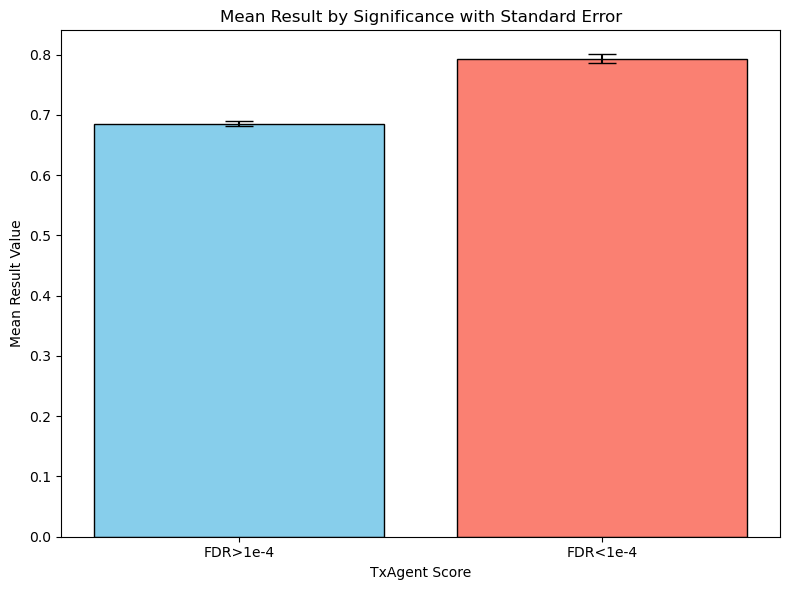

In [162]:


low_significance = male_trj_gptllama_v3[male_trj_gptllama_v3['FDR'] > 0.0001]['Result'].tolist()
high_significance = male_trj_gptllama_v3[male_trj_gptllama_v3['FDR'] < 0.0001]['Result'].tolist()

# Calculate the mean and standard error for each group
low_mean = np.mean(low_significance)
high_mean = np.mean(high_significance)
low_se = np.std(low_significance) / np.sqrt(len(low_significance))
high_se = np.std(high_significance) / np.sqrt(len(high_significance))

# Plotting the bar plot
plt.figure(figsize=(8, 6))
plt.bar(
    ['FDR>1e-4', 'FDR<1e-4'], # X-axis labels for the bars
    [low_mean, high_mean],    # The height of the bars (the mean)
    yerr=[low_se, high_se],   # The size of the error bars
    capsize=10,               # The width of the error bar caps
    color=['skyblue', 'salmon'],
    edgecolor='black'
)

plt.title('Mean Result by Significance with Standard Error')
plt.ylabel('Mean Result Value')
plt.xlabel('TxAgent Score')
plt.grid(False)
plt.tight_layout()
plt.show()

In [163]:
import numpy as np
from scipy.stats import fisher_exact, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

def compare_binary_lists(listA, listB):
    # Convert to numpy arrays
    arrA = np.array(listA)
    arrB = np.array(listB)
    
    # Counts
    n1_ones = arrA.sum()
    n1_zeros = len(arrA) - n1_ones
    n2_ones = arrB.sum()
    n2_zeros = len(arrB) - n2_ones
    
    # Build contingency table
    table = np.array([[n1_ones, n1_zeros],
                      [n2_ones, n2_zeros]])
    
    print("Contingency Table:")
    print(table)
    
    # Fisher's exact test
    odds_ratio, p_fisher = fisher_exact(table)
    
    # Chi-square test
    chi2, p_chi, dof, exp = chi2_contingency(table)
    
    # Two-proportion z-test
    count = np.array([n1_ones, n2_ones])
    nobs = np.array([len(arrA), len(arrB)])
    zstat, p_z = proportions_ztest(count, nobs)
    
    results = {
        "Fisher_exact": {"odds_ratio": odds_ratio, "p_value": p_fisher},
        "Chi_square": {"chi2": chi2, "p_value": p_chi},
        "Two_proportion_ztest": {"z": zstat, "p_value": p_z}
    }
    
    return results



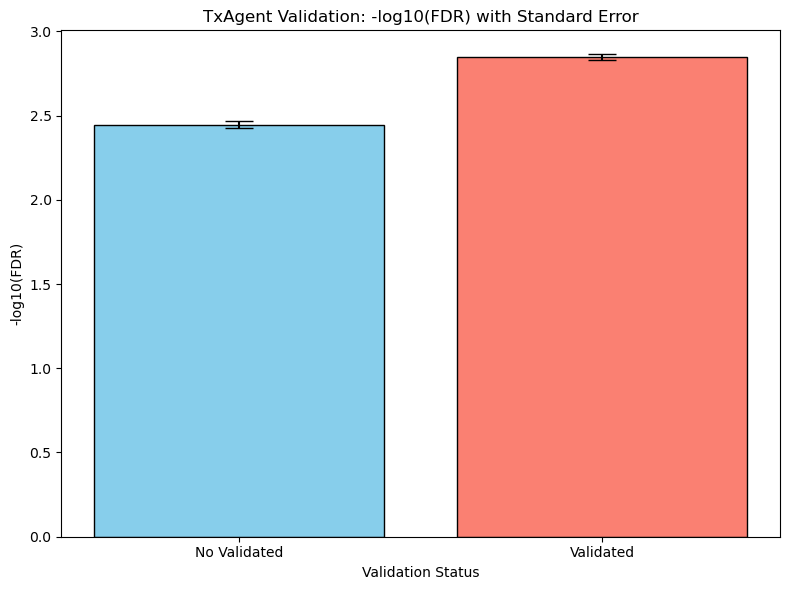

In [164]:
#Let's compare the llm_validated vs no_validated


# Extract lists
no_llm_validated = male_trj_gptllama_v3[male_trj_gptllama_v3['Result'] == 0]['FDR'].tolist()
llm_validated = male_trj_gptllama_v3[male_trj_gptllama_v3['Result'] == 1]['FDR'].tolist()

# Apply -log10 transform (avoid issues with FDR=0)
def safe_log_transform(values):
    values = np.array(values, dtype=float)
    values[values <= 0] = np.min(values[values > 0]) * 0.5  # replace 0 or negatives with small value
    return -np.log10(values)

no_llm_log = safe_log_transform(no_llm_validated)
llm_log = safe_log_transform(llm_validated)

# Calculate mean and standard error on transformed values
low_mean = np.mean(no_llm_log)
high_mean = np.mean(llm_log)
low_se = np.std(no_llm_log, ddof=1) / np.sqrt(len(no_llm_log))
high_se = np.std(llm_log, ddof=1) / np.sqrt(len(llm_log))

# Plotting
plt.figure(figsize=(8, 6))
plt.bar(
    ['No Validated', 'Validated'],
    [low_mean, high_mean],
    yerr=[low_se, high_se],
    capsize=10,
    color=['skyblue', 'salmon'],
    edgecolor='black'
)

plt.title('TxAgent Validation: -log10(FDR) with Standard Error')
plt.ylabel('-log10(FDR)')
plt.xlabel('Validation Status')
plt.grid(False)
plt.tight_layout()

plt.savefig("Figures/Fig5D_TxAgent_Mol_male_v2026_official.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Figures/Fig5D_TxAgent_Mol_male_v2026_official.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [166]:


# Ensure output folder exists
os.makedirs("output", exist_ok=True)

# Prepare data for Excel
df_source = pd.DataFrame({
    "Validation Status": ["No Validated", "Validated"],
    "n_points": [len(no_llm_log), len(llm_log)],
    "mean_-log10FDR": [low_mean, high_mean],
    "standard_error": [low_se, high_se]
})

# Path to Excel file
excel_path = "output/SourceData.xlsx"

# If file already exists, append new sheet; otherwise, create new
with pd.ExcelWriter(excel_path, engine="openpyxl", mode="a" if os.path.exists(excel_path) else "w", if_sheet_exists="replace") as writer:
    df_source.to_excel(writer, sheet_name="Fig5F", index=False)


In [167]:
print(ttest_ind(no_llm_log, llm_log, equal_var=False))




TtestResult(statistic=-14.836633473114668, pvalue=2.1491636280490798e-49, df=13016.762797297313)


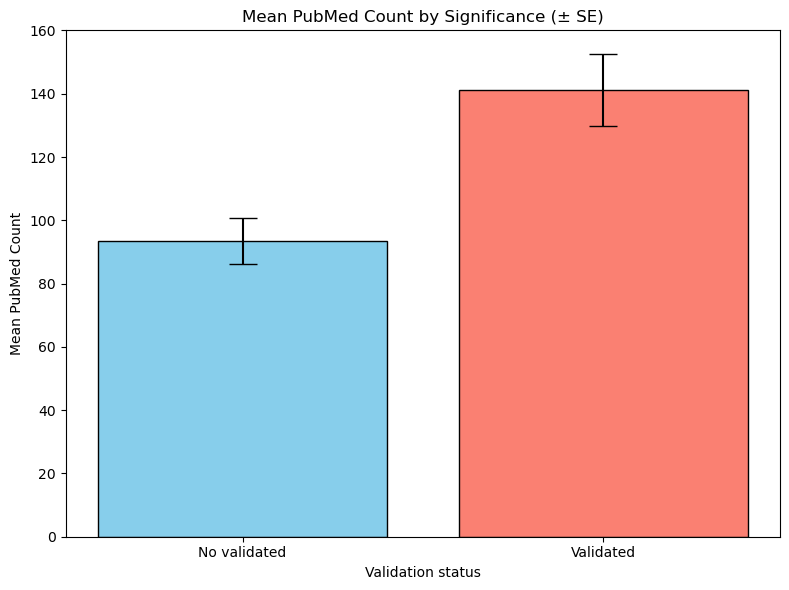

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import ast

low_significance = []
high_significance = []
missing_trj_drug = []

# Collect No-validated from TxAgent
for idx, row in male_trj_gptllama_v3[male_trj_gptllama_v3['Result']==0].iterrows():
    trj = str(row['Trajectory'])
    drug = row['Drug']
    avg_pubmed = male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df[(male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df['Trajectory'] == trj) & (male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df['Drug'] == drug)]['PubMed count avg'].values[0]
    low_significance.append(avg_pubmed)

# Collect Validated from TxAgent
for idx, row in male_trj_gptllama_v3[male_trj_gptllama_v3['Result']==1].iterrows():
    trj = str(row['Trajectory'])
    drug = row['Drug']
    avg_pubmed = male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df[(male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df['Trajectory'] == trj) & (male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df['Drug'] == drug)]['PubMed count avg'].values[0]
    high_significance.append(avg_pubmed)

# Safeguard against empty lists
def mean_se(data):
    if len(data) == 0:
        return 0, 0
    mean = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(len(data))
    return mean, se

low_mean, low_se = mean_se(low_significance)
high_mean, high_se = mean_se(high_significance)

# Plotting
plt.figure(figsize=(8, 6))
plt.bar(
    ['No validated', 'Validated'],
    [low_mean, high_mean],
    yerr=[low_se, high_se],
    capsize=10,
    color=['skyblue', 'salmon'],
    edgecolor='black'
)

plt.title('Mean PubMed Count by Significance (± SE)')
plt.ylabel('Mean PubMed Count')
plt.xlabel('Validation status')
plt.tight_layout()
plt.savefig("Figures/Fig5E_TxAgent_Pubmed_male_v2026_official.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Figures/Fig5E_TxAgent_Pubmed_male_v2026_official.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [70]:

# Ensure output folder exists
os.makedirs("output", exist_ok=True)

# Prepare source data
df_source = pd.DataFrame({
    "Validation Status": ["No validated", "Validated"],
    "n_points": [len(low_significance), len(high_significance)],
    "mean_pubmed_count": [low_mean, high_mean],
    "standard_error": [low_se, high_se]
})

# Excel file path
excel_path = "output/SourceData.xlsx"

# Write to Excel: create file if doesn't exist, append if exists
with pd.ExcelWriter(excel_path, engine="openpyxl", mode="a" if os.path.exists(excel_path) else "w", if_sheet_exists="replace") as writer:
    df_source.to_excel(writer, sheet_name="Fig5G", index=False)


In [71]:
print(ttest_ind(low_significance, high_significance, equal_var=False))

TtestResult(statistic=-3.5251453130043946, pvalue=0.0004242097037631696, df=19725.953156304306)


In [72]:
print(np.mean(high_significance), np.mean(low_significance))

141.10578258076484 93.470404595713


Pearson: r = 0.982, p = 4.288e-07
Spearman: ρ = 0.855, p = 1.637e-03


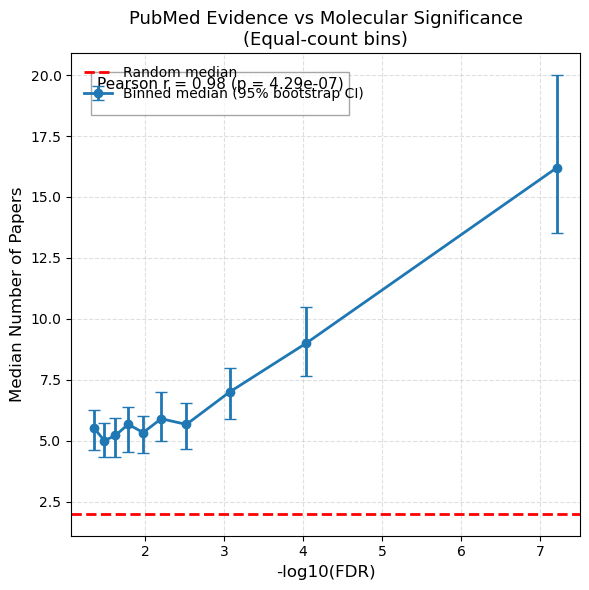

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import pandas as pd

# -----------------------------
# Prepare data
# -----------------------------
avg_num_papers_list = []
fdr_list = []

for idx, row in male_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.iterrows():
    avg_num_papers_list.append(row["PubMed count avg"])
    fdr_list.append(float(row["FDR"]))

fdr_array = np.array(fdr_list, dtype=float)

# Avoid log10(0)
positive_min = np.min(fdr_array[fdr_array > 0])
fdr_array[fdr_array <= 0] = positive_min * 0.5

fdr_log = -np.log10(fdr_array)
avg_num_papers_array = np.array(avg_num_papers_list, dtype=float)

# -----------------------------
# Equal-count binning
# -----------------------------
num_bins = 10
bins = np.quantile(fdr_log, np.linspace(0, 1, num_bins + 1))

bin_centers = []
binned_medians = []
binned_ci_low = []
binned_ci_high = []

def bootstrap_ci(data, n_boot=5000):
    boot_medians = []
    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_medians.append(np.median(sample))
    return np.percentile(boot_medians, [2.5, 97.5])

for i in range(num_bins):
    mask = (fdr_log >= bins[i]) & (fdr_log < bins[i+1]) if i < num_bins - 1 \
       else (fdr_log >= bins[i]) & (fdr_log <= bins[i+1])
    values = avg_num_papers_array[mask]
    
    if len(values) > 2:
        # X-axis = mean FDR in bin (location descriptor)
        bin_centers.append(np.mean(fdr_log[mask]))
        
        # Y-axis = median PubMed (robust estimator)
        median_val = np.median(values)
        ci_low, ci_high = bootstrap_ci(values)
        
        binned_medians.append(median_val)
        binned_ci_low.append(median_val - ci_low)
        binned_ci_high.append(ci_high - median_val)
    else:
        bin_centers.append(np.nan)
        binned_medians.append(np.nan)
        binned_ci_low.append(np.nan)
        binned_ci_high.append(np.nan)

bin_centers = np.array(bin_centers)
binned_medians = np.array(binned_medians)

# -----------------------------
# Correlations (on binned medians)
# -----------------------------
valid = ~np.isnan(bin_centers) & ~np.isnan(binned_medians)

pearson_corr, pearson_p = pearsonr(bin_centers[valid], binned_medians[valid])
spearman_corr, spearman_p = spearmanr(bin_centers[valid], binned_medians[valid])

print(f"Pearson: r = {pearson_corr:.3f}, p = {pearson_p:.3e}")
print(f"Spearman: ρ = {spearman_corr:.3f}, p = {spearman_p:.3e}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6,6))

plt.errorbar(
    bin_centers,
    binned_medians,
    yerr=[binned_ci_low, binned_ci_high],
    fmt='o-',
    capsize=4,
    linewidth=2,
    label='Binned median (95% bootstrap CI)'
)

# Median of random distribution
random_median = np.median(random_male_drug_df['PubMed count avg'])
plt.axhline(
    y=random_median,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Random median'
)

plt.xlabel('-log10(FDR)', fontsize=12)
plt.ylabel('Median Number of Papers', fontsize=12)
plt.title('PubMed Evidence vs Molecular Significance\n(Equal-count bins)', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.4)

# Annotate correlations (Spearman emphasized)
plt.text(
    0.05, 0.95,
    #f"Spearman ρ = {spearman_corr:.2f} (p = {spearman_p:.2e})\n"
    f"Pearson r = {pearson_corr:.2f} (p = {pearson_p:.2e})\n",
    transform=plt.gca().transAxes,
    fontsize=11,
    va='top',
    ha='left',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
)

plt.legend(frameon=False)
plt.tight_layout()

plt.savefig("Figures/Fig5E_PubMed_Mol_Male_Corr_FINAL_2026.pdf",
            format="pdf", dpi=300, bbox_inches="tight")

plt.savefig("Figures/Fig5E_PubMed_Mol_Male_Corr_FINAL_2026.svg",
            format="svg", dpi=300, bbox_inches="tight")

plt.show()

In [74]:
import pandas as pd
import numpy as np

# -----------------------------
# Count points per bin again
# -----------------------------
bin_counts = []

for i in range(num_bins):
    mask = (fdr_log >= bins[i]) & (fdr_log < bins[i+1])
    bin_counts.append(np.sum(mask))

# -----------------------------
# Build dataframe for binned data
# -----------------------------
df_bins = pd.DataFrame({
    "bin_center_-log10FDR (mean)": bin_centers,
    "median_pubmed_count": binned_medians,
    "ci_lower_95": binned_medians - np.array(binned_ci_low),
    "ci_upper_95": binned_medians + np.array(binned_ci_high),
    "n_points": bin_counts
})

# -----------------------------
# Correlation results
# -----------------------------
df_corr = pd.DataFrame({
    "metric": [
        "Pearson_r",
        "Pearson_p",
        "Spearman_rho",
        "Spearman_p"
    ],
    "value": [
        pearson_corr,
        pearson_p,
        spearman_corr,
        spearman_p
    ]
})

# -----------------------------
# Random reference median
# -----------------------------
df_random = pd.DataFrame({
    "metric": ["Random_median_pubmed"],
    "value": [random_median]
})

# -----------------------------
# Write to Excel (single sheet)
# -----------------------------
excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    
    df_bins.to_excel(writer, sheet_name="Fig5E_bins", index=False)
    df_corr.to_excel(writer, sheet_name="Fig5E_correlation", index=False)
    df_random.to_excel(writer, sheet_name="Fig5E_random", index=False)

print(f"Saved results to {excel_path}")

Saved results to output/SourceData.xlsx


In [173]:
validated_male_trj_gptllama_v3 = male_trj_gptllama_v3[male_trj_gptllama_v3['Result'] == 1]
len(validated_male_trj_gptllama_v3)

13842

In [193]:
# We use str.extract() which is optimized for pandas series
# This regex looks for our keywords, then captures everything up to a semicolon, comma, or period.
pattern = r"(?:managing symptoms like|managing|used for)\s+([^;,\.]+)"

# Extract the text and make it lowercase to ensure consistency 
validated_male_trj_gptllama_v3['Extracted_Symptom'] = validated_male_trj_gptllama_v3['reasoning_short'].str.extract(pattern, expand=False).str.lower().str.strip()

# 1. Clean up trailing words like 'in' 
validated_male_trj_gptllama_v3['Extracted_Symptom'] = validated_male_trj_gptllama_v3['Extracted_Symptom'].str.replace(r'\s+in$', '', regex=True)

# 2. NEW: Scrub the word "managing" from anywhere in the captured string
validated_male_trj_gptllama_v3['Extracted_Symptom'] = validated_male_trj_gptllama_v3['Extracted_Symptom'].str.replace(r'\bmanaging\b\s*', '', regex=True)

# 3. NEW: Scrub the word "guidelines" and its surrounding parentheses
validated_male_trj_gptllama_v3['Extracted_Symptom'] = validated_male_trj_gptllama_v3['Extracted_Symptom'].str.replace(r'\s*\(?guidelines?\)?\s*', '', regex=True)

# 4. Final cleanup to fix any double spaces or weird spacing left behind by the removals
validated_male_trj_gptllama_v3['Extracted_Symptom'] = validated_male_trj_gptllama_v3['Extracted_Symptom'].str.replace(r'\s+', ' ', regex=True).str.strip()


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_52349/2854268743.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validated_male_trj_gptllama_v3['Extracted_Symptom'] = validated_male_trj_gptllama_v3['reasoning_short'].str.extract(pattern, expand=False).str.lower().str.strip()
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_52349/2854268743.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validated_male_trj_gptllama_v3['Extracted_Symptom'] = validated_male_trj_gptllama_v3['Extract

In [194]:

from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering

# 1. Isolate the unique terms to save compute time
# (Assuming your extracted column is named 'Extracted_Symptom')
unique_symptoms = validated_male_trj_gptllama_v3['Extracted_Symptom'].dropna().unique()
print(f"Embedding {len(unique_symptoms)} unique terms...")

# 2. Load the SapBERT model
model = SentenceTransformer("cambridgeltl/SapBERT-from-PubMedBERT-fulltext")

# 3. Generate Embeddings (this should take less than a minute for 3,700 terms)
embeddings = model.encode(unique_symptoms, show_progress_bar=True)

# 4. Cluster based on semantic similarity
# distance_threshold: Lower = stricter matching. 0.15 to 0.20 is a good starting point for Cosine distance.
clustering_model = AgglomerativeClustering(
    n_clusters=None, 
    distance_threshold=0.25, 
    metric='cosine', 
    linkage='average'
)
cluster_labels = clustering_model.fit_predict(embeddings)

# 5. Build a mapping dictionary to rename the clusters
cluster_df = pd.DataFrame({
    'Original_Term': unique_symptoms, 
    'Cluster_ID': cluster_labels
})

# We need to pick one "Representative Name" for each cluster.
# A solid heuristic for medical terms is picking the shortest string in the cluster 
# (e.g., between "severe anxiety symptoms" and "anxiety", it will pick "anxiety").
representative_mapping = cluster_df.groupby('Cluster_ID')['Original_Term'].apply(
    lambda x: min(x, key=len)
).to_dict()

# Map the representative names to the cluster dataframe
cluster_df['Harmonized_Term'] = cluster_df['Cluster_ID'].map(representative_mapping)

# 6. Apply the mapping back to your massive dataset
mapping_dict = dict(zip(cluster_df['Original_Term'], cluster_df['Harmonized_Term']))
validated_male_trj_gptllama_v3['Harmonized_Symptom'] = validated_male_trj_gptllama_v3['Extracted_Symptom'].map(mapping_dict)

print(f"Reduced {len(unique_symptoms)} terms down to {cluster_df['Cluster_ID'].nunique()} harmonized categories!")

No sentence-transformers model found with name cambridgeltl/SapBERT-from-PubMedBERT-fulltext. Creating a new one with mean pooling.


Embedding 3572 unique terms...


Batches:   0%|          | 0/112 [00:00<?, ?it/s]

Reduced 3572 terms down to 1190 harmonized categories!


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_52349/3767090692.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validated_male_trj_gptllama_v3['Harmonized_Symptom'] = validated_male_trj_gptllama_v3['Extracted_Symptom'].map(mapping_dict)


In [212]:
validated_male_trj_gptllama_v3 = validated_male_trj_gptllama_v3.dropna()

In [239]:
validated_male_trj_gptllama_v3.to_csv("output/validated_male_trj_gptllama_v3_with_symptoms.csv", index=False)   

In [5]:
validated_male_trj_gptllama_v3 = pd.read_csv("output/validated_male_trj_gptllama_v3_with_symptoms.csv")

Most Present Drug: Polaprezinc (67 appearances)
Most Used Mechanism: agitation in substance-related disorders (544 appearances)
Most Common Trajectory: 351 (239 appearances)


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_38386/3814988926.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_trj.values, y=top_trj.index, ax=axes[0], palette="Oranges_r")
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_38386/3814988926.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_mechs.values, y=top_mechs.index, ax=axes[1], palette="Greens_r")
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_38386/3814988926.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_drugs.values, y

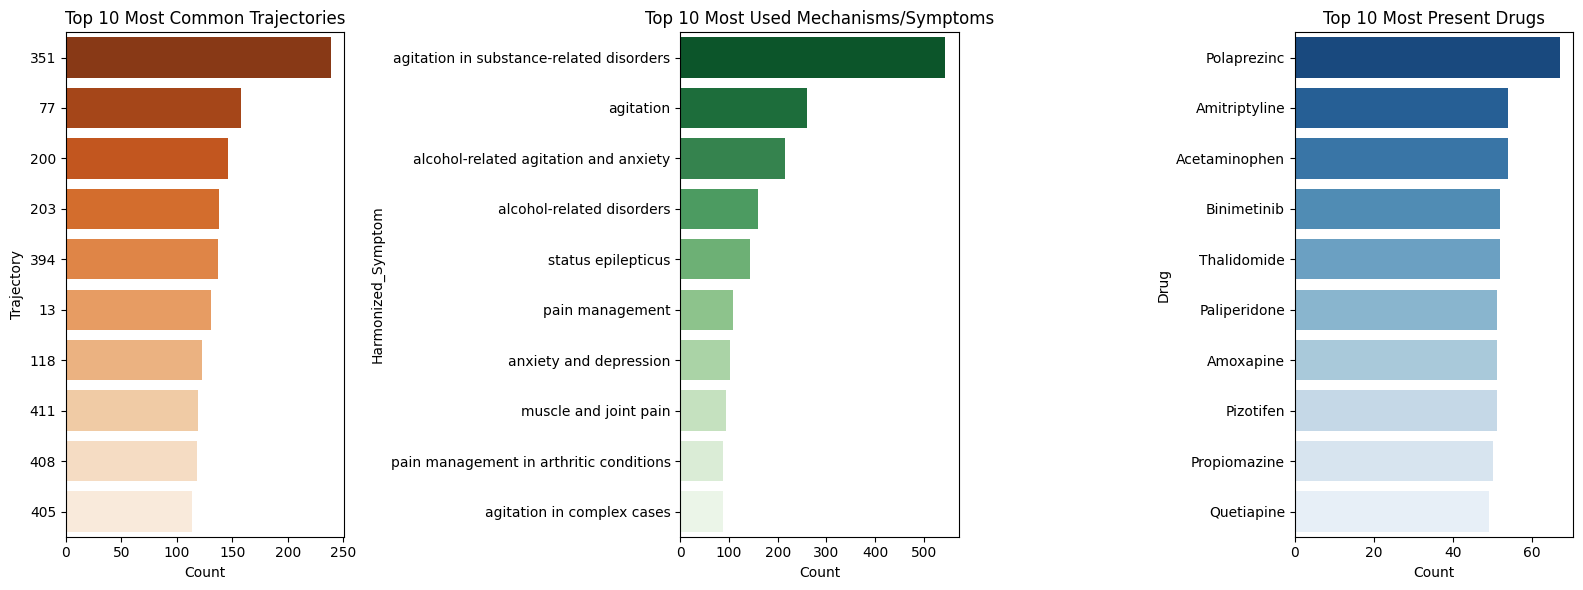

In [6]:

# 1. Find the most present Drug and Mechanism
top_drugs = validated_male_trj_gptllama_v3['Drug'].value_counts().head(10)
top_mechs = validated_male_trj_gptllama_v3['Harmonized_Symptom'].value_counts().head(10)
top_trj = validated_male_trj_gptllama_v3['Trajectory'].value_counts().head(10)

print(f"Most Present Drug: {top_drugs.index[0]} ({top_drugs.iloc[0]} appearances)")
print(f"Most Used Mechanism: {top_mechs.index[0]} ({top_mechs.iloc[0]} appearances)")
print(f"Most Common Trajectory: {top_trj.index[0]} ({top_trj.iloc[0]} appearances)")

# 2. Visualize with Horizontal Bar Charts
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
# Plot Top Trajectories
sns.barplot(x=top_trj.values, y=top_trj.index, ax=axes[0], palette="Oranges_r")
axes[0].set_title('Top 10 Most Common Trajectories')
axes[0].set_xlabel('Count')

# Plot Top Mechanisms
sns.barplot(x=top_mechs.values, y=top_mechs.index, ax=axes[1], palette="Greens_r")
axes[1].set_title('Top 10 Most Used Mechanisms/Symptoms')
axes[1].set_xlabel('Count')

# Plot Top Drugs
sns.barplot(x=top_drugs.values, y=top_drugs.index, ax=axes[2], palette="Blues_r")
axes[2].set_title('Top 10 Most Present Drugs')
axes[2].set_xlabel('Count')

plt.tight_layout()

#plt.savefig("Figures/Fig5H_Reasoning_TxAgent_Male.pdf",
#            format="pdf", dpi=300, bbox_inches="tight")

#plt.savefig("Figures/Fig5H_Reasoning_TxAgent_Male.svg",
#            format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [230]:

# Prepare DataFrames
df_drugs = pd.DataFrame({
    "Drug": top_drugs.index,
    "Count": top_drugs.values
})

df_mechs = pd.DataFrame({
    "Mechanism/Symptom": top_mechs.index,
    "Count": top_mechs.values
})

df_trj = pd.DataFrame({
    "Trajectory": top_trj.index,
    "Count": top_trj.values
})

# Save to Excel
excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_drugs.to_excel(writer, sheet_name="Fig5H_Drugs", index=False)
    df_mechs.to_excel(writer, sheet_name="Fig5H_Mechanisms", index=False)
    df_trj.to_excel(writer, sheet_name="Fig5H_Trajectories", index=False)

print(f"Saved Fig5H source data to {excel_path}")

Saved Fig5H source data to output/SourceData.xlsx


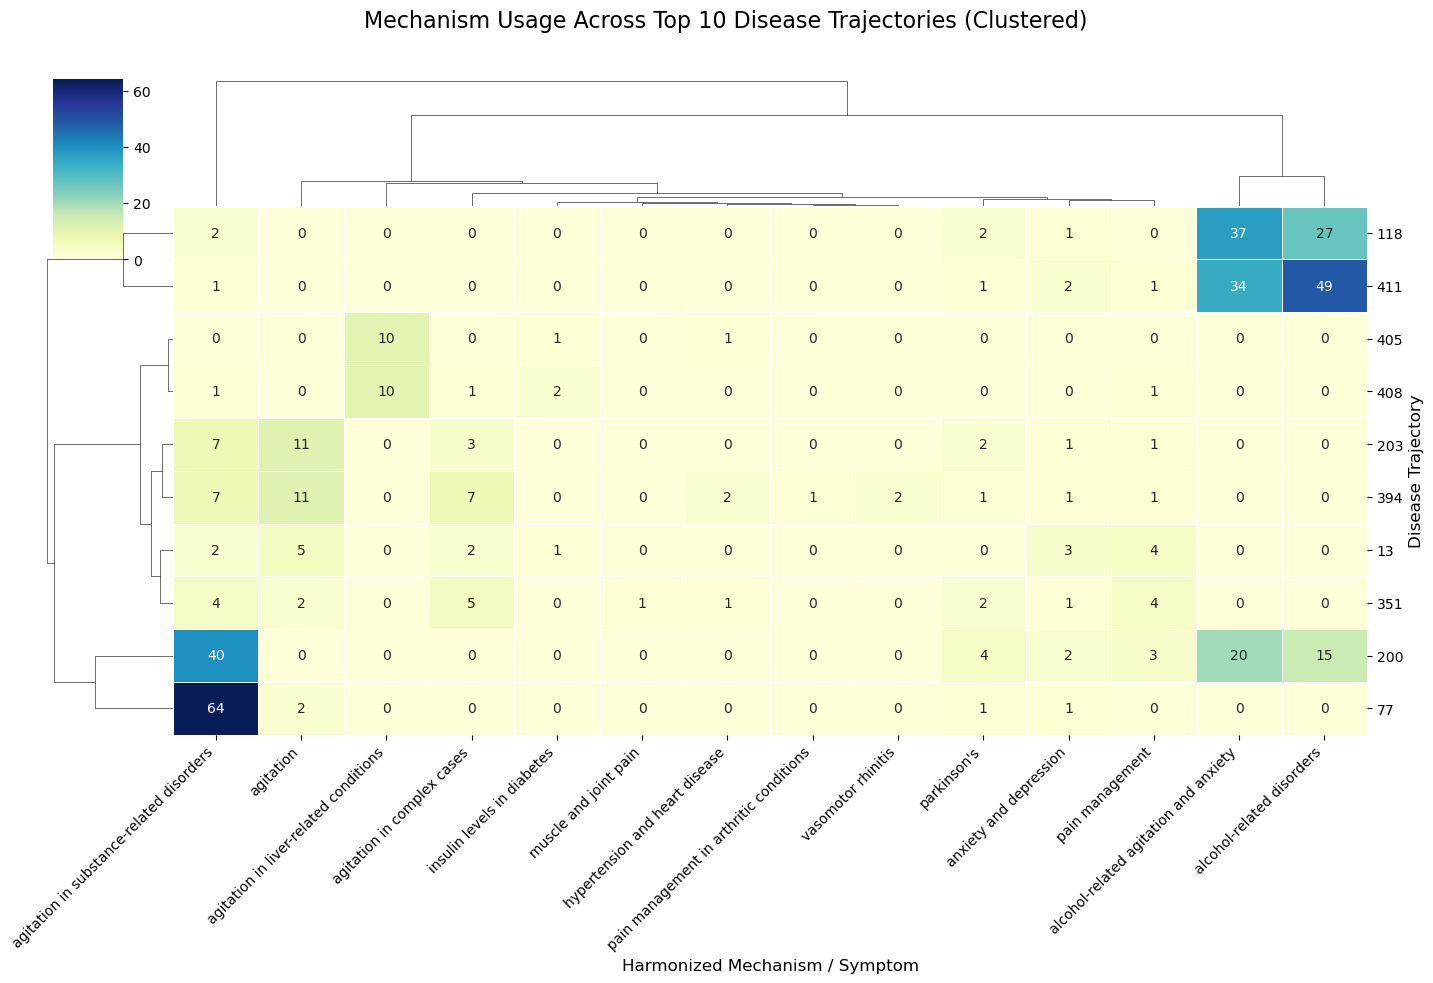

In [214]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the names of the top 10 disease trajectories and top 15 mechanisms
top_trajectories = validated_male_trj_gptllama_v3['Trajectory'].value_counts().head(10).index
top_15_mechs = validated_male_trj_gptllama_v3['Harmonized_Symptom'].value_counts().head(15).index

# 2. Filter the dataframe to only include these top categories
filtered_df = validated_male_trj_gptllama_v3[
    validated_male_trj_gptllama_v3['Trajectory'].isin(top_trajectories) & 
    validated_male_trj_gptllama_v3['Harmonized_Symptom'].isin(top_15_mechs)
]

# 3. Create a pivot table (crosstab) counting occurrences
mech_disease_matrix = pd.crosstab(
    filtered_df['Trajectory'], 
    filtered_df['Harmonized_Symptom']
)

# 4. Plot the Clustered Heatmap
# figsize might need tweaking depending on your screen/notebook
cluster_plot = sns.clustermap(
    mech_disease_matrix, 
    cmap="YlGnBu", 
    annot=True,      # Show the actual numbers in the squares
    fmt="d",         # Format numbers as integers
    linewidths=.5,
    figsize=(14, 10),
    dendrogram_ratio=(.1, .2), # Adjusts the size of the clustering trees
    cbar_pos=(0.02, 0.8, 0.05, 0.18) # Adjust colorbar position
)

# Adjust titles and labels 
cluster_plot.fig.suptitle('Mechanism Usage Across Top 10 Disease Trajectories (Clustered)', fontsize=16, y=1.05)
cluster_plot.ax_heatmap.set_xlabel('Harmonized Mechanism / Symptom', fontsize=12)
cluster_plot.ax_heatmap.set_ylabel('Disease Trajectory', fontsize=12)

# Rotate mechanism labels for readability
plt.setp(cluster_plot.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.setp(cluster_plot.ax_heatmap.get_yticklabels(), rotation=0)

plt.show()

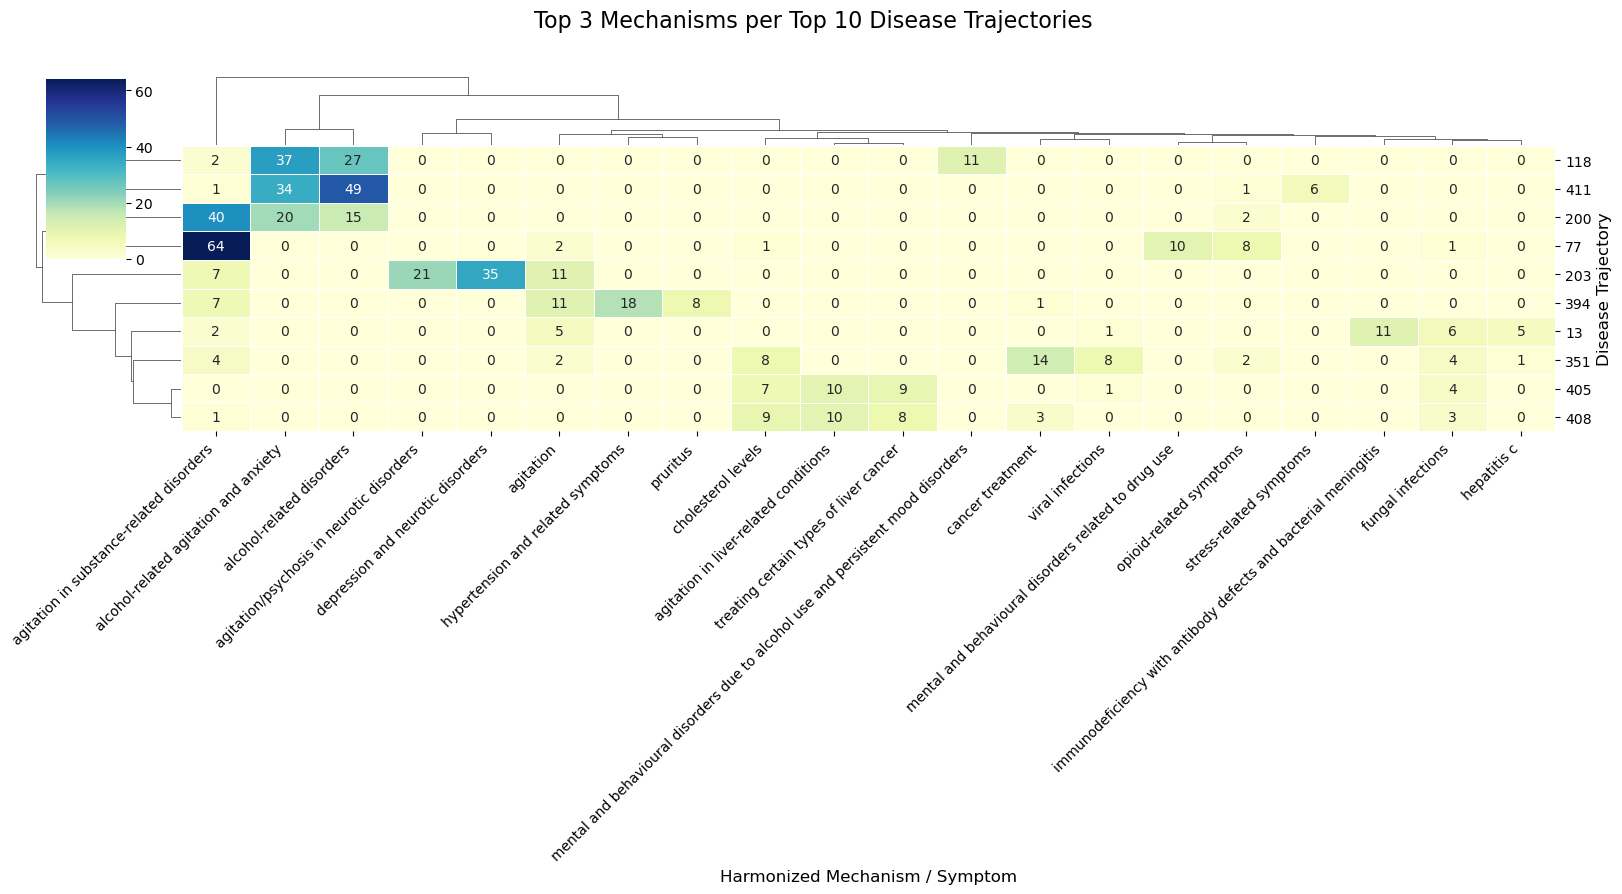

In [215]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the names of the top 10 disease trajectories
top_trajectories = validated_male_trj_gptllama_v3['Trajectory'].value_counts().head(10).index

# 2. Filter the dataframe to only include these top trajectories
filtered_traj_df = validated_male_trj_gptllama_v3[
    validated_male_trj_gptllama_v3['Trajectory'].isin(top_trajectories)
]

# 3. Find the top mechanisms *specifically for each* of these top trajectories
top_mechs_per_traj = set()
n_top_mechs = 3 # Adjust this to show the top 3, 5, etc., mechanisms per trajectory

for traj in top_trajectories:
    # Get the top mechanisms for this specific trajectory
    top_mechs = filtered_traj_df[filtered_traj_df['Trajectory'] == traj]['Harmonized_Symptom'].value_counts().head(n_top_mechs).index
    
    # Add them to our unique set
    top_mechs_per_traj.update(top_mechs)

# Convert the set back to a list for filtering
top_mechs_list = list(top_mechs_per_traj)

# 4. Filter the dataframe again to only include these specific mechanisms
final_filtered_df = filtered_traj_df[
    filtered_traj_df['Harmonized_Symptom'].isin(top_mechs_list)
]

# 5. Create the pivot table (crosstab)
mech_disease_matrix = pd.crosstab(
    final_filtered_df['Trajectory'], 
    final_filtered_df['Harmonized_Symptom']
)

# 6. Plot the Clustered Heatmap
cluster_plot = sns.clustermap(
    mech_disease_matrix, 
    cmap="YlGnBu", 
    annot=True,      
    fmt="d",         
    linewidths=.5,
    figsize=(16, 10),
    dendrogram_ratio=(.1, .2)
)

# Adjust titles and labels 
cluster_plot.fig.suptitle(f'Top {n_top_mechs} Mechanisms per Top 10 Disease Trajectories', fontsize=16, y=1.05)
cluster_plot.ax_heatmap.set_xlabel('Harmonized Mechanism / Symptom', fontsize=12)
cluster_plot.ax_heatmap.set_ylabel('Disease Trajectory', fontsize=12)

# Rotate mechanism labels for readability
plt.setp(cluster_plot.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.setp(cluster_plot.ax_heatmap.get_yticklabels(), rotation=0)

plt.show()

In [216]:
import pandas as pd
import plotly.graph_objects as go

# 1. Group the data to get the counts (edges) and drop all zeros
edges = final_filtered_df.groupby(['Trajectory', 'Harmonized_Symptom']).size().reset_index(name='Weight')
edges = edges[edges['Weight'] > 0] # Strictly drop the zeros!

# 2. Create a unique list of all nodes (Trajectories + Mechanisms)
all_nodes = list(edges['Trajectory'].unique()) + list(edges['Harmonized_Symptom'].unique())

# Create a mapping dictionary to convert names to integer indices (required by Plotly)
node_indices = {name: i for i, name in enumerate(all_nodes)}

# 3. Map the sources and targets to their integer indices
source_indices = edges['Trajectory'].map(node_indices).tolist()
target_indices = edges['Harmonized_Symptom'].map(node_indices).tolist()
weights = edges['Weight'].tolist()

# 4. Build the Sankey Diagram
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = all_nodes,
      color = "lightblue"
    ),
    link = dict(
      source = source_indices,
      target = target_indices,
      value = weights,
      color = "rgba(173, 216, 230, 0.4)" # Light blue transparent links
    )
)])

fig.update_layout(
    title_text=f"Flow of Top {n_top_mechs} Mechanisms per Top 10 Disease Trajectories", 
    font_size=12,
    height=800
)

fig.show()

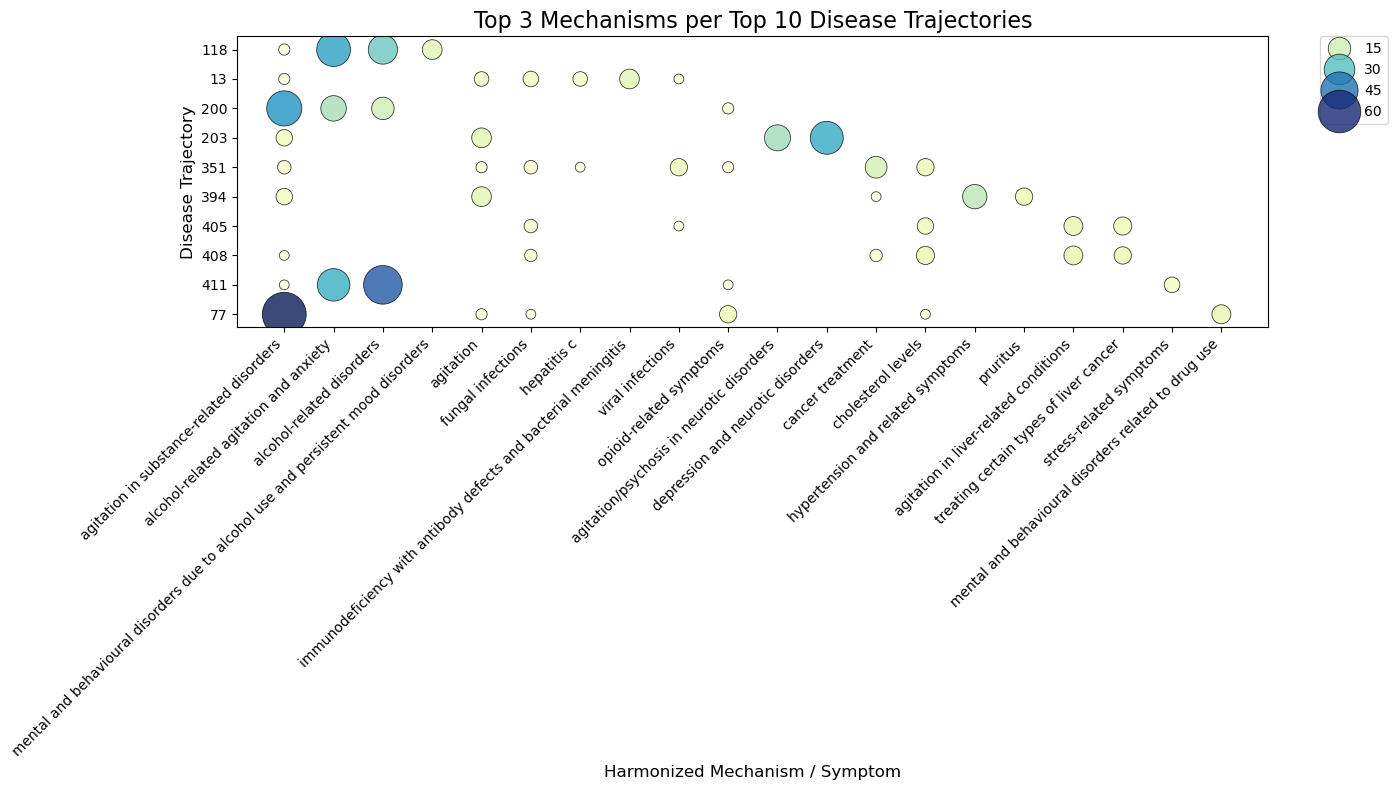

In [217]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group the data and drop the zeros
bubble_data = final_filtered_df.groupby(['Trajectory', 'Harmonized_Symptom']).size().reset_index(name='Count')
bubble_data = bubble_data[bubble_data['Count'] > 0] # Remove zeros

# 2. Plot the Bubble Chart
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=bubble_data, 
    x='Harmonized_Symptom', 
    y='Trajectory', 
    size='Count', 
    hue='Count', 
    sizes=(50, 1000), # Min and max size of the bubbles
    palette='YlGnBu', 
    edgecolor='black',
    alpha=0.8
)

plt.title(f'Top {n_top_mechs} Mechanisms per Top 10 Disease Trajectories', fontsize=16)
plt.xlabel('Harmonized Mechanism / Symptom', fontsize=12)
plt.ylabel('Disease Trajectory', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Move the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

In [32]:
import pandas as pd
import plotly.graph_objects as go

# 1. Isolate the top 10 trajectories
top_trajectories = validated_male_trj_gptllama_v3['Trajectory'].value_counts().head(10).index
filtered_traj_df = validated_male_trj_gptllama_v3[validated_male_trj_gptllama_v3['Trajectory'].isin(top_trajectories)]

# 2. Find top 3 mechanisms per trajectory, then top 3 drugs per (trajectory, mechanism)
records = []
n_top = 3

for traj in top_trajectories:
    traj_subset = filtered_traj_df[filtered_traj_df['Trajectory'] == traj]
    top_symptoms = traj_subset['Harmonized_Symptom'].value_counts().head(n_top).index

    for symptom in top_symptoms:
        symptom_subset = traj_subset[traj_subset['Harmonized_Symptom'] == symptom]
        top_drugs = symptom_subset['Drug'].value_counts().head(1).index #only the top 1 drug

        for drug in top_drugs:
            mask = (
                (filtered_traj_df['Trajectory'] == traj) &
                (filtered_traj_df['Harmonized_Symptom'] == symptom) &
                (filtered_traj_df['Drug'] == drug)
            )
            records.append(filtered_traj_df[mask])

# 3. Reconstruct final_df from valid, coherent chains only
final_df = pd.concat(records).drop_duplicates()

# *** Rebuild node sets from final_df so color logic works correctly ***
top_mechs_per_traj = set(final_df['Harmonized_Symptom'].unique())
top_drugs_per_traj = set(final_df['Drug'].unique())

# ---------------------------------------------------------
# 4. FLOW CALCULATION
# ---------------------------------------------------------
# Stage 1: Trajectory -> Mechanism
flow1 = final_df.groupby(['Trajectory', 'Harmonized_Symptom']).size().reset_index(name='Weight')
flow1.columns = ['Source', 'Target', 'Weight']

# Stage 2: Mechanism -> Drug
flow2 = final_df.groupby(['Harmonized_Symptom', 'Drug']).size().reset_index(name='Weight')
flow2.columns = ['Source', 'Target', 'Weight']

# Combine the flows
all_flows = pd.concat([flow1, flow2], ignore_index=True)
all_flows = all_flows[all_flows['Weight'] > 0]

# 5. Create a unique list of all nodes
all_nodes = list(dict.fromkeys(list(all_flows['Source'].unique()) + list(all_flows['Target'].unique())))
node_indices = {name: i for i, name in enumerate(all_nodes)}

source_indices = all_flows['Source'].map(node_indices).tolist()
target_indices = all_flows['Target'].map(node_indices).tolist()
weights = all_flows['Weight'].tolist()

# ---------------------------------------------------------
# 6. COLOR MAPPING
# ---------------------------------------------------------
node_color_map = {
    'Trajectory': 'rgba(255, 127, 14, 0.9)',  # Solid Orange
    'Mechanism':  'rgba(44, 160, 44, 0.9)',   # Solid Green
    'Drug':       'rgba(31, 119, 180, 0.9)'   # Solid Blue
}

link_color_map = {
    'Mechanism': 'rgba(44, 160, 44, 0.35)',   # Transparent Green → flowing into Mechanism
    'Drug':      'rgba(31, 119, 180, 0.35)'   # Transparent Blue  → flowing into Drug
}

# Assign colors to each node
node_colors = []
for node in all_nodes:
    if node in set(top_trajectories):
        node_colors.append(node_color_map['Trajectory'])
    elif node in top_mechs_per_traj:
        node_colors.append(node_color_map['Mechanism'])
    elif node in top_drugs_per_traj:
        node_colors.append(node_color_map['Drug'])
    else:
        node_colors.append('rgba(150, 150, 150, 0.8)')  # Fallback gray

# Assign colors to each link based on its TARGET node
link_colors = []
for target in all_flows['Target']:
    if target in top_mechs_per_traj:
        link_colors.append(link_color_map['Mechanism'])  # Flowing into a Mechanism → green
    elif target in top_drugs_per_traj:
        link_colors.append(link_color_map['Drug'])        # Flowing into a Drug → blue
    else:
        link_colors.append('rgba(200, 200, 200, 0.3)')    # Fallback gray

# ---------------------------------------------------------
# 7. Build the 3-Tier Sankey Diagram
# ---------------------------------------------------------
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_nodes,
        color=node_colors
    ),
    link=dict(
        source=source_indices,
        target=target_indices,
        value=weights,
        color=link_colors
    )
)])

fig.update_layout(
    title_text=f"Clinical Flow: Top 10 Disease Trajectories → Mechanisms → Top {n_top} Drugs",
    font_size=12,
    height=900,
    plot_bgcolor='white'
)

fig.write_image("Figures/Fig5I_Reasoning_TxAgent_Male_Sankey.pdf")
fig.write_image("Figures/Fig5I_Reasoning_TxAgent_Male_Sankey.svg")

fig.show()

In [9]:

# --- Prepare Nodes DataFrame ---
df_nodes = pd.DataFrame({
    "Node": all_nodes,
    "Type": [
        "Trajectory" if node in top_trajectories else
        "Mechanism" if node in top_mechs_per_traj else
        "Drug" if node in top_drugs_per_traj else "Other"
        for node in all_nodes
    ],
    "Index": range(len(all_nodes)),
    "Color": node_colors
})

# --- Prepare Links DataFrame ---
df_links = pd.DataFrame({
    "Source": all_flows['Source'],
    "Target": all_flows['Target'],
    "Weight": all_flows['Weight'],
    "Color": link_colors
})

# --- Save to Excel ---
excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_nodes.to_excel(writer, sheet_name="Fig5I_Nodes", index=False)
    df_links.to_excel(writer, sheet_name="Fig5I_Links", index=False)

print(f"Saved Fig5I Sankey source data to {excel_path}")

Saved Fig5I Sankey source data to output/SourceData.xlsx


In [8]:
filtered_traj_df[filtered_traj_df['Trajectory']=='411']['Disease Consensus Name List'].tolist()[0]


"['degenerative diseases of nervous system', 'mental and behavioural disorders due to use of alcohol', 'reaction to severe stress, and adjustment disorders']"

In [75]:

female_trj_gptllama_v3 = pd.read_excel(open('output/TxAgent 2026 v2/female_trj_mol_drug_v2026_officialTaxAgentReasoning.xlsx', 'rb'))  
random_female_trj_gptllama_v3 = pd.read_excel(open('output/TxAgent 2026 v2/random_female_trj_mol_drug_v2026_officialTaxAgent.xlsx', 'rb')) 

In [178]:
real_rate = female_trj_gptllama_v3["Result"].mean()
random_rate = random_female_trj_gptllama_v3["Result"].mean()

print(f"Real validation rate = {real_rate:.4f}")
print(f"Random validation rate = {random_rate:.4f}")
print(f"Fold enrichment = {real_rate / random_rate:.2f}")

Real validation rate = 0.6847
Random validation rate = 0.3272
Fold enrichment = 2.09


In [179]:
import numpy as np
from scipy.stats import fisher_exact, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

def compare_binary_lists(listA, listB):
    # Convert to numpy arrays
    arrA = np.array(listA)
    arrB = np.array(listB)
    
    # Counts
    n1_ones = arrA.sum()
    n1_zeros = len(arrA) - n1_ones
    n2_ones = arrB.sum()
    n2_zeros = len(arrB) - n2_ones
    
    # Build contingency table
    table = np.array([[n1_ones, n1_zeros],
                      [n2_ones, n2_zeros]])
    
    print("Contingency Table:")
    print(table)
    
    # Fisher's exact test
    odds_ratio, p_fisher = fisher_exact(table)
    
    # Chi-square test
    chi2, p_chi, dof, exp = chi2_contingency(table)
    
    # Two-proportion z-test
    count = np.array([n1_ones, n2_ones])
    nobs = np.array([len(arrA), len(arrB)])
    zstat, p_z = proportions_ztest(count, nobs)
    
    results = {
        "Fisher_exact": {"odds_ratio": odds_ratio, "p_value": p_fisher},
        "Chi_square": {"chi2": chi2, "p_value": p_chi},
        "Two_proportion_ztest": {"z": zstat, "p_value": p_z}
    }
    
    return results



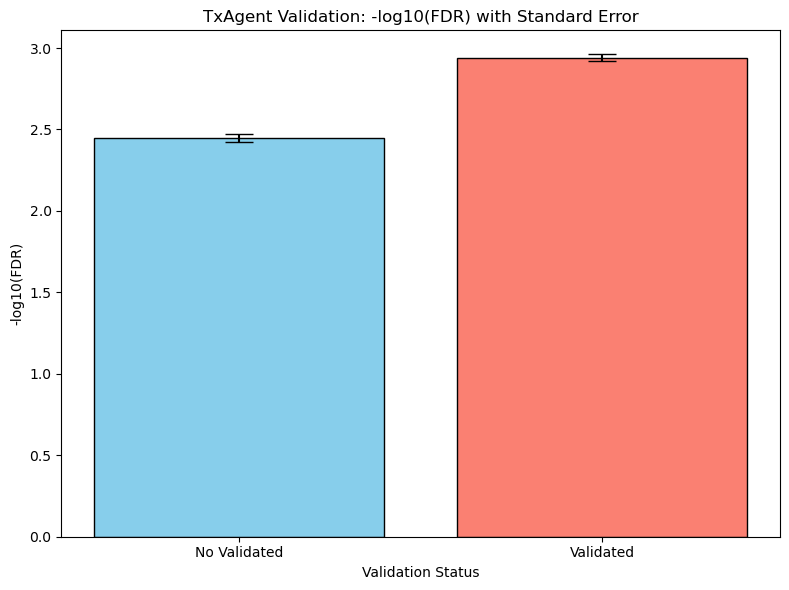

In [180]:
#Let's compare the llm_validated vs no_validated


# Extract lists
no_llm_validated = female_trj_gptllama_v3[female_trj_gptllama_v3['Result'] == 0]['FDR'].tolist()
llm_validated = female_trj_gptllama_v3[female_trj_gptllama_v3['Result'] == 1]['FDR'].tolist()

# Apply -log10 transform (avoid issues with FDR=0)
def safe_log_transform(values):
    values = np.array(values, dtype=float)
    values[values <= 0] = np.min(values[values > 0]) * 0.5  # replace 0 or negatives with small value
    return -np.log10(values)

no_llm_log = safe_log_transform(no_llm_validated)
llm_log = safe_log_transform(llm_validated)

# Calculate mean and standard error on transformed values
low_mean = np.mean(no_llm_log)
high_mean = np.mean(llm_log)
low_se = np.std(no_llm_log, ddof=1) / np.sqrt(len(no_llm_log))
high_se = np.std(llm_log, ddof=1) / np.sqrt(len(llm_log))

# Plotting
plt.figure(figsize=(8, 6))
plt.bar(
    ['No Validated', 'Validated'],
    [low_mean, high_mean],
    yerr=[low_se, high_se],
    capsize=10,
    color=['skyblue', 'salmon'],
    edgecolor='black'
)

plt.title('TxAgent Validation: -log10(FDR) with Standard Error')
plt.ylabel('-log10(FDR)')
plt.xlabel('Validation Status')
plt.grid(False)
plt.tight_layout()

plt.savefig("Figures/SF7F_TxAgent_Mol_female_v2026_official.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Figures/SF7F_TxAgent_Mol_female_v2026_official.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [181]:


# Ensure output folder exists
os.makedirs("output", exist_ok=True)

# Prepare data for Excel
df_source = pd.DataFrame({
    "Validation Status": ["No Validated", "Validated"],
    "n_points": [len(no_llm_log), len(llm_log)],
    "mean_-log10FDR": [low_mean, high_mean],
    "standard_error": [low_se, high_se]
})

# Path to Excel file
excel_path = "output/SourceData.xlsx"

# If file already exists, append new sheet; otherwise, create new
with pd.ExcelWriter(excel_path, engine="openpyxl", mode="a" if os.path.exists(excel_path) else "w", if_sheet_exists="replace") as writer:
    df_source.to_excel(writer, sheet_name="SF7F", index=False)


In [182]:
print(ttest_ind(no_llm_log, llm_log, equal_var=False))




TtestResult(statistic=-15.833459598229584, pvalue=5.82182395395175e-56, df=13510.831964603623)


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_75023/3060160342.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for idx, row in female_trj_gptllama_v3[male_trj_gptllama_v3['Result']==1].iterrows():


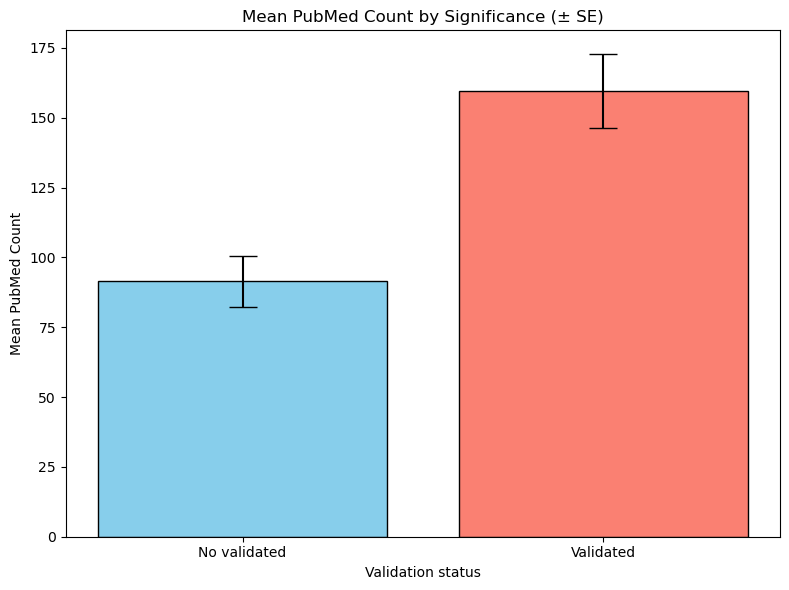

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import ast

low_significance = []
high_significance = []
missing_trj_drug = []

# Collect No-validated from TxAgent
for idx, row in female_trj_gptllama_v3[female_trj_gptllama_v3['Result']==0].iterrows():
    trj = str(row['Trajectory'])
    drug = row['Drug']
    avg_pubmed = female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df[(female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df['Trajectory'] == trj) & (female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df['Drug'] == drug)]['PubMed count avg'].values[0]
    low_significance.append(avg_pubmed)

# Collect Validated from TxAgent
for idx, row in female_trj_gptllama_v3[male_trj_gptllama_v3['Result']==1].iterrows():
    trj = str(row['Trajectory'])
    drug = row['Drug']
    avg_pubmed = female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df[(female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df['Trajectory'] == trj) & (female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df['Drug'] == drug)]['PubMed count avg'].values[0]
    high_significance.append(avg_pubmed)

# Safeguard against empty lists
def mean_se(data):
    if len(data) == 0:
        return 0, 0
    mean = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(len(data))
    return mean, se

low_mean, low_se = mean_se(low_significance)
high_mean, high_se = mean_se(high_significance)

# Plotting
plt.figure(figsize=(8, 6))
plt.bar(
    ['No validated', 'Validated'],
    [low_mean, high_mean],
    yerr=[low_se, high_se],
    capsize=10,
    color=['skyblue', 'salmon'],
    edgecolor='black'
)

plt.title('Mean PubMed Count by Significance (± SE)')
plt.ylabel('Mean PubMed Count')
plt.xlabel('Validation status')
plt.tight_layout()
plt.savefig("Figures/SF7G_TxAgent_Pubmed_female_v2026_official.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Figures/SF7G_TxAgent_Pubmed_male_v2026_official.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [77]:

# Ensure output folder exists
os.makedirs("output", exist_ok=True)

# Prepare source data
df_source = pd.DataFrame({
    "Validation Status": ["No validated", "Validated"],
    "n_points": [len(low_significance), len(high_significance)],
    "mean_pubmed_count": [low_mean, high_mean],
    "standard_error": [low_se, high_se]
})

# Excel file path
excel_path = "output/SourceData.xlsx"

# Write to Excel: create file if doesn't exist, append if exists
with pd.ExcelWriter(excel_path, engine="openpyxl", mode="a" if os.path.exists(excel_path) else "w", if_sheet_exists="replace") as writer:
    df_source.to_excel(writer, sheet_name="SF7G", index=False)


In [78]:
print(ttest_ind(low_significance, high_significance, equal_var=False))

TtestResult(statistic=-4.264850738448554, pvalue=2.01043977075502e-05, df=18216.414299250766)


In [79]:
print(np.mean(high_significance), np.mean(low_significance))

159.57313178731957 91.44203641322066


Pearson: r = 0.981, p = 6.013e-07
Spearman: ρ = 0.730, p = 1.651e-02


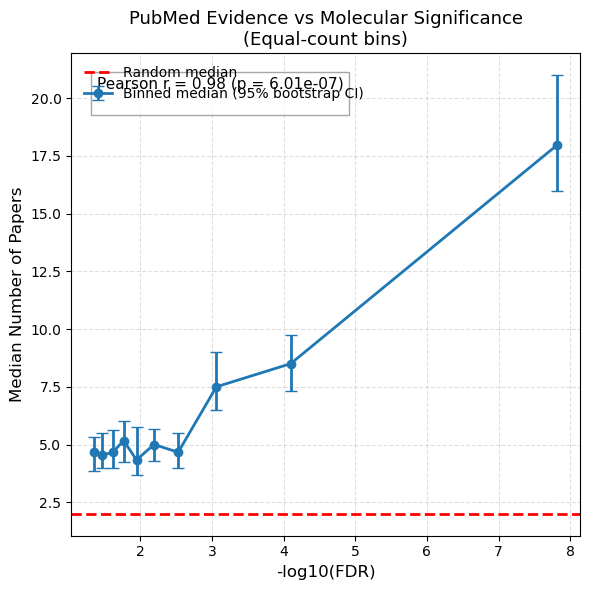

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import pandas as pd

# -----------------------------
# Prepare data
# -----------------------------
avg_num_papers_list = []
fdr_list = []

for idx, row in female_trajectories_dict_filtered_unique_drug_intersection_sigfdr_df.iterrows():
    avg_num_papers_list.append(row["PubMed count avg"])
    fdr_list.append(float(row["FDR"]))

fdr_array = np.array(fdr_list, dtype=float)

# Avoid log10(0)
positive_min = np.min(fdr_array[fdr_array > 0])
fdr_array[fdr_array <= 0] = positive_min * 0.5

fdr_log = -np.log10(fdr_array)
avg_num_papers_array = np.array(avg_num_papers_list, dtype=float)

# -----------------------------
# Equal-count binning
# -----------------------------
num_bins = 10
bins = np.quantile(fdr_log, np.linspace(0, 1, num_bins + 1))

bin_centers = []
binned_medians = []
binned_ci_low = []
binned_ci_high = []

def bootstrap_ci(data, n_boot=5000):
    boot_medians = []
    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_medians.append(np.median(sample))
    return np.percentile(boot_medians, [2.5, 97.5])

for i in range(num_bins):
    mask = (fdr_log >= bins[i]) & (fdr_log < bins[i+1]) if i < num_bins - 1 \
       else (fdr_log >= bins[i]) & (fdr_log <= bins[i+1])
    values = avg_num_papers_array[mask]
    
    if len(values) > 2:
        # X-axis = mean FDR in bin (location descriptor)
        bin_centers.append(np.mean(fdr_log[mask]))
        
        # Y-axis = median PubMed (robust estimator)
        median_val = np.median(values)
        ci_low, ci_high = bootstrap_ci(values)
        
        binned_medians.append(median_val)
        binned_ci_low.append(median_val - ci_low)
        binned_ci_high.append(ci_high - median_val)
    else:
        bin_centers.append(np.nan)
        binned_medians.append(np.nan)
        binned_ci_low.append(np.nan)
        binned_ci_high.append(np.nan)

bin_centers = np.array(bin_centers)
binned_medians = np.array(binned_medians)

# -----------------------------
# Correlations (on binned medians)
# -----------------------------
valid = ~np.isnan(bin_centers) & ~np.isnan(binned_medians)

pearson_corr, pearson_p = pearsonr(bin_centers[valid], binned_medians[valid])
spearman_corr, spearman_p = spearmanr(bin_centers[valid], binned_medians[valid])

print(f"Pearson: r = {pearson_corr:.3f}, p = {pearson_p:.3e}")
print(f"Spearman: ρ = {spearman_corr:.3f}, p = {spearman_p:.3e}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6,6))

plt.errorbar(
    bin_centers,
    binned_medians,
    yerr=[binned_ci_low, binned_ci_high],
    fmt='o-',
    capsize=4,
    linewidth=2,
    label='Binned median (95% bootstrap CI)'
)

# Median of random distribution
random_median = np.median(random_male_drug_df['PubMed count avg'])
plt.axhline(
    y=random_median,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Random median'
)

plt.xlabel('-log10(FDR)', fontsize=12)
plt.ylabel('Median Number of Papers', fontsize=12)
plt.title('PubMed Evidence vs Molecular Significance\n(Equal-count bins)', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.4)

# Annotate correlations (Spearman emphasized)
plt.text(
    0.05, 0.95,
    #f"Spearman ρ = {spearman_corr:.2f} (p = {spearman_p:.2e})\n"
    f"Pearson r = {pearson_corr:.2f} (p = {pearson_p:.2e})\n",
    transform=plt.gca().transAxes,
    fontsize=11,
    va='top',
    ha='left',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
)

plt.legend(frameon=False)
plt.tight_layout()

plt.savefig("Figures/SF7E_PubMed_Mol_Feale_Corr_FINAL_2026.pdf",
            format="pdf", dpi=300, bbox_inches="tight")

plt.savefig("Figures/SF7E_PubMed_Mol_Female_Corr_FINAL_2026.svg",
            format="svg", dpi=300, bbox_inches="tight")

plt.show()

In [183]:
validated_female_trj_gptllama_v3 = female_trj_gptllama_v3[female_trj_gptllama_v3['Result'] == 1]
len(validated_female_trj_gptllama_v3)

12267

In [184]:
# We use str.extract() which is optimized for pandas series
# This regex looks for our keywords, then captures everything up to a semicolon, comma, or period.
pattern = r"(?:managing symptoms like|managing|used for)\s+([^;,\.]+)"

# Extract the text and make it lowercase to ensure consistency 
validated_female_trj_gptllama_v3['Extracted_Symptom'] = validated_female_trj_gptllama_v3['reasoning_short'].str.extract(pattern, expand=False).str.lower().str.strip()

# 1. Clean up trailing words like 'in' 
validated_female_trj_gptllama_v3['Extracted_Symptom'] = validated_female_trj_gptllama_v3['Extracted_Symptom'].str.replace(r'\s+in$', '', regex=True)

# 2. NEW: Scrub the word "managing" from anywhere in the captured string
validated_female_trj_gptllama_v3['Extracted_Symptom'] = validated_female_trj_gptllama_v3['Extracted_Symptom'].str.replace(r'\bmanaging\b\s*', '', regex=True)

# 3. NEW: Scrub the word "guidelines" and its surrounding parentheses
validated_female_trj_gptllama_v3['Extracted_Symptom'] = validated_female_trj_gptllama_v3['Extracted_Symptom'].str.replace(r'\s*\(?guidelines?\)?\s*', '', regex=True)

# 4. Final cleanup to fix any double spaces or weird spacing left behind by the removals
validated_female_trj_gptllama_v3['Extracted_Symptom'] = validated_female_trj_gptllama_v3['Extracted_Symptom'].str.replace(r'\s+', ' ', regex=True).str.strip()


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_37892/308715899.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validated_female_trj_gptllama_v3['Extracted_Symptom'] = validated_female_trj_gptllama_v3['reasoning_short'].str.extract(pattern, expand=False).str.lower().str.strip()
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_37892/308715899.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validated_female_trj_gptllama_v3['Extracted_Symptom'] = validated_female_trj_gptllama_v3['E

In [273]:

from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering

# 1. Isolate the unique terms to save compute time
# (Assuming your extracted column is named 'Extracted_Symptom')
unique_symptoms = validated_female_trj_gptllama_v3['Extracted_Symptom'].dropna().unique()
print(f"Embedding {len(unique_symptoms)} unique terms...")

# 2. Load the SapBERT model
model = SentenceTransformer("cambridgeltl/SapBERT-from-PubMedBERT-fulltext")

# 3. Generate Embeddings (this should take less than a minute for 3,700 terms)
embeddings = model.encode(unique_symptoms, show_progress_bar=True)

# 4. Cluster based on semantic similarity
# distance_threshold: Lower = stricter matching. 0.15 to 0.20 is a good starting point for Cosine distance.
clustering_model = AgglomerativeClustering(
    n_clusters=None, 
    distance_threshold=0.25, 
    metric='cosine', 
    linkage='average'
)
cluster_labels = clustering_model.fit_predict(embeddings)

# 5. Build a mapping dictionary to rename the clusters
cluster_df = pd.DataFrame({
    'Original_Term': unique_symptoms, 
    'Cluster_ID': cluster_labels
})

# We need to pick one "Representative Name" for each cluster.
# A solid heuristic for medical terms is picking the shortest string in the cluster 
# (e.g., between "severe anxiety symptoms" and "anxiety", it will pick "anxiety").
representative_mapping = cluster_df.groupby('Cluster_ID')['Original_Term'].apply(
    lambda x: min(x, key=len)
).to_dict()

# Map the representative names to the cluster dataframe
cluster_df['Harmonized_Term'] = cluster_df['Cluster_ID'].map(representative_mapping)

# 6. Apply the mapping back to your massive dataset
mapping_dict = dict(zip(cluster_df['Original_Term'], cluster_df['Harmonized_Term']))
validated_female_trj_gptllama_v3['Harmonized_Symptom'] = validated_female_trj_gptllama_v3['Extracted_Symptom'].map(mapping_dict)

print(f"Reduced {len(unique_symptoms)} terms down to {cluster_df['Cluster_ID'].nunique()} harmonized categories!")

Embedding 3307 unique terms...


No sentence-transformers model found with name cambridgeltl/SapBERT-from-PubMedBERT-fulltext. Creating a new one with mean pooling.
python(37656) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Batches:   0%|          | 0/104 [00:00<?, ?it/s]

Reduced 3307 terms down to 1129 harmonized categories!


In [274]:
validated_female_trj_gptllama_v3 = validated_female_trj_gptllama_v3.dropna()

In [275]:
validated_female_trj_gptllama_v3.to_csv("output/validated_female_trj_gptllama_v3_with_symptoms.csv", index=False)   

In [33]:
validated_female_trj_gptllama_v3 = pd.read_csv("output/validated_female_trj_gptllama_v3_with_symptoms.csv")

Most Present Drug: Polaprezinc (66 appearances)
Most Used Mechanism: sedation in substance-related presentations (482 appearances)
Most Common Trajectory: 65_103 (211 appearances)


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_38386/3241676138.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_38386/3241676138.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_38386/3241676138.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




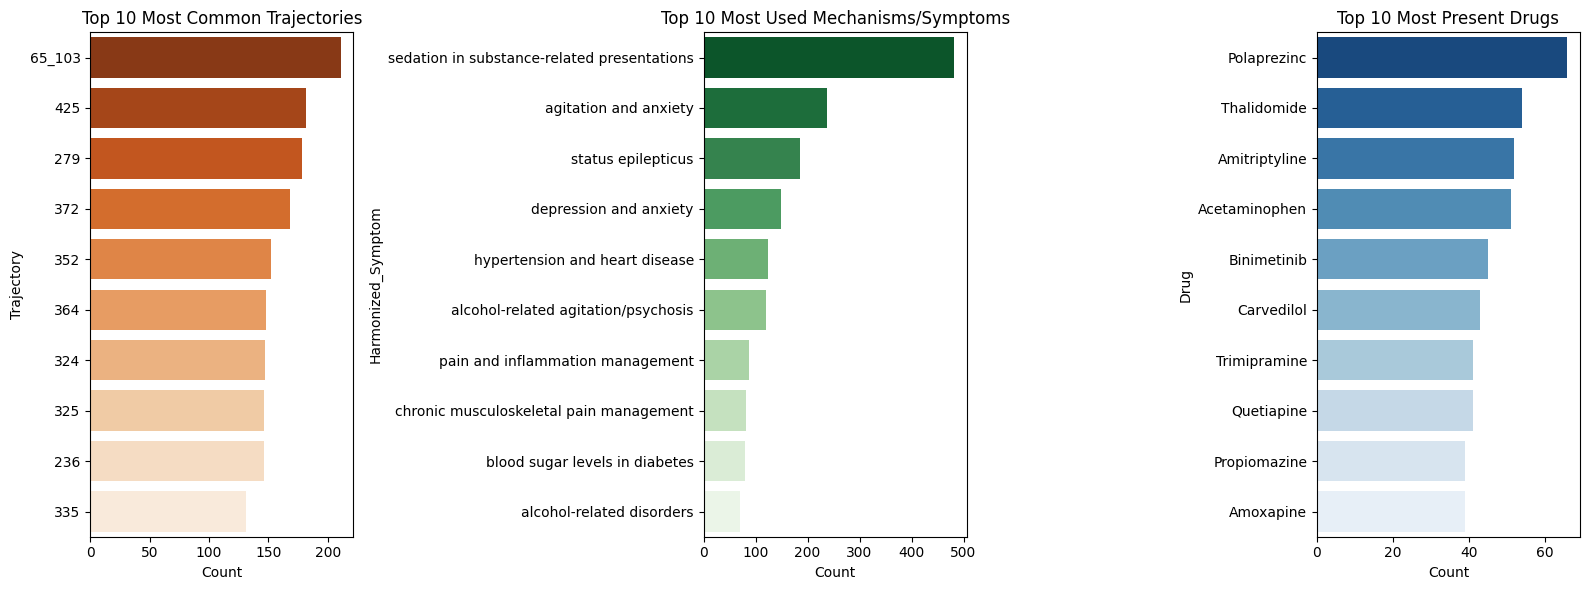

In [34]:

# 1. Find the most present Drug and Mechanism
top_drugs = validated_female_trj_gptllama_v3['Drug'].value_counts().head(10)
top_mechs = validated_female_trj_gptllama_v3['Harmonized_Symptom'].value_counts().head(10)
top_trj = validated_female_trj_gptllama_v3['Trajectory'].value_counts().head(10)

print(f"Most Present Drug: {top_drugs.index[0]} ({top_drugs.iloc[0]} appearances)")
print(f"Most Used Mechanism: {top_mechs.index[0]} ({top_mechs.iloc[0]} appearances)")
print(f"Most Common Trajectory: {top_trj.index[0]} ({top_trj.iloc[0]} appearances)")

# 2. Visualize with Horizontal Bar Charts
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
# Plot Top Trajectories
sns.barplot(x=top_trj.values, y=top_trj.index, ax=axes[0], palette="Oranges_r")
axes[0].set_title('Top 10 Most Common Trajectories')
axes[0].set_xlabel('Count')

# Plot Top Mechanisms
sns.barplot(x=top_mechs.values, y=top_mechs.index, ax=axes[1], palette="Greens_r")
axes[1].set_title('Top 10 Most Used Mechanisms/Symptoms')
axes[1].set_xlabel('Count')

# Plot Top Drugs
sns.barplot(x=top_drugs.values, y=top_drugs.index, ax=axes[2], palette="Blues_r")
axes[2].set_title('Top 10 Most Present Drugs')
axes[2].set_xlabel('Count')

plt.tight_layout()

plt.savefig("Figures/SuppFig8X_Reasoning_TxAgent_Female.pdf",
            format="pdf", dpi=300, bbox_inches="tight")

plt.savefig("Figures/SuppFig8X_Reasoning_TxAgent_Female.svg",
            format="svg", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:

# Prepare DataFrames
df_drugs = pd.DataFrame({
    "Drug": top_drugs.index,
    "Count": top_drugs.values
})

df_mechs = pd.DataFrame({
    "Mechanism/Symptom": top_mechs.index,
    "Count": top_mechs.values
})

df_trj = pd.DataFrame({
    "Trajectory": top_trj.index,
    "Count": top_trj.values
})

# Save to Excel
excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_drugs.to_excel(writer, sheet_name="Fig5H_Drugs", index=False)
    df_mechs.to_excel(writer, sheet_name="Fig5H_Mechanisms", index=False)
    df_trj.to_excel(writer, sheet_name="Fig5H_Trajectories", index=False)

print(f"Saved Fig5H source data to {excel_path}")

Saved Fig5H source data to output/SourceData.xlsx


In [36]:
import pandas as pd
import plotly.graph_objects as go

# 1. Isolate the top 10 trajectories
top_trajectories = validated_female_trj_gptllama_v3['Trajectory'].value_counts().head(10).index
filtered_traj_df = validated_female_trj_gptllama_v3[validated_female_trj_gptllama_v3['Trajectory'].isin(top_trajectories)]

# 2. Find top 3 mechanisms per trajectory, then top 3 drugs per (trajectory, mechanism)
records = []
n_top = 3

for traj in top_trajectories:
    traj_subset = filtered_traj_df[filtered_traj_df['Trajectory'] == traj]
    top_symptoms = traj_subset['Harmonized_Symptom'].value_counts().head(n_top).index

    for symptom in top_symptoms:
        symptom_subset = traj_subset[traj_subset['Harmonized_Symptom'] == symptom]
        top_drugs = symptom_subset['Drug'].value_counts().head(1).index #only the top 1 drug

        for drug in top_drugs:
            mask = (
                (filtered_traj_df['Trajectory'] == traj) &
                (filtered_traj_df['Harmonized_Symptom'] == symptom) &
                (filtered_traj_df['Drug'] == drug)
            )
            records.append(filtered_traj_df[mask])

# 3. Reconstruct final_df from valid, coherent chains only
final_df = pd.concat(records).drop_duplicates()

# *** Rebuild node sets from final_df so color logic works correctly ***
top_mechs_per_traj = set(final_df['Harmonized_Symptom'].unique())
top_drugs_per_traj = set(final_df['Drug'].unique())

# ---------------------------------------------------------
# 4. FLOW CALCULATION
# ---------------------------------------------------------
# Stage 1: Trajectory -> Mechanism
flow1 = final_df.groupby(['Trajectory', 'Harmonized_Symptom']).size().reset_index(name='Weight')
flow1.columns = ['Source', 'Target', 'Weight']

# Stage 2: Mechanism -> Drug
flow2 = final_df.groupby(['Harmonized_Symptom', 'Drug']).size().reset_index(name='Weight')
flow2.columns = ['Source', 'Target', 'Weight']

# Combine the flows
all_flows = pd.concat([flow1, flow2], ignore_index=True)
all_flows = all_flows[all_flows['Weight'] > 0]

# 5. Create a unique list of all nodes
all_nodes = list(dict.fromkeys(list(all_flows['Source'].unique()) + list(all_flows['Target'].unique())))
node_indices = {name: i for i, name in enumerate(all_nodes)}

source_indices = all_flows['Source'].map(node_indices).tolist()
target_indices = all_flows['Target'].map(node_indices).tolist()
weights = all_flows['Weight'].tolist()

# ---------------------------------------------------------
# 6. COLOR MAPPING
# ---------------------------------------------------------
node_color_map = {
    'Trajectory': 'rgba(255, 127, 14, 0.9)',  # Solid Orange
    'Mechanism':  'rgba(44, 160, 44, 0.9)',   # Solid Green
    'Drug':       'rgba(31, 119, 180, 0.9)'   # Solid Blue
}

link_color_map = {
    'Mechanism': 'rgba(44, 160, 44, 0.35)',   # Transparent Green → flowing into Mechanism
    'Drug':      'rgba(31, 119, 180, 0.35)'   # Transparent Blue  → flowing into Drug
}

# Assign colors to each node
node_colors = []
for node in all_nodes:
    if node in set(top_trajectories):
        node_colors.append(node_color_map['Trajectory'])
    elif node in top_mechs_per_traj:
        node_colors.append(node_color_map['Mechanism'])
    elif node in top_drugs_per_traj:
        node_colors.append(node_color_map['Drug'])
    else:
        node_colors.append('rgba(150, 150, 150, 0.8)')  # Fallback gray

# Assign colors to each link based on its TARGET node
link_colors = []
for target in all_flows['Target']:
    if target in top_mechs_per_traj:
        link_colors.append(link_color_map['Mechanism'])  # Flowing into a Mechanism → green
    elif target in top_drugs_per_traj:
        link_colors.append(link_color_map['Drug'])        # Flowing into a Drug → blue
    else:
        link_colors.append('rgba(200, 200, 200, 0.3)')    # Fallback gray

# ---------------------------------------------------------
# 7. Build the 3-Tier Sankey Diagram
# ---------------------------------------------------------
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_nodes,
        color=node_colors
    ),
    link=dict(
        source=source_indices,
        target=target_indices,
        value=weights,
        color=link_colors
    )
)])

fig.update_layout(
    title_text=f"Clinical Flow: Top 10 Disease Trajectories → Mechanisms → Top {n_top} Drugs",
    font_size=12,
    height=900,
    plot_bgcolor='white'
)

fig.write_image("Figures/Sup8XX_Reasoning_TxAgent_Female_Sankey.pdf")
fig.write_image("Figures/Sup8XX_Reasoning_TxAgent_Female_Sankey.svg")

fig.show()

In [ ]:

# --- Prepare Nodes DataFrame ---
df_nodes = pd.DataFrame({
    "Node": all_nodes,
    "Type": [
        "Trajectory" if node in top_trajectories else
        "Mechanism" if node in top_mechs_per_traj else
        "Drug" if node in top_drugs_per_traj else "Other"
        for node in all_nodes
    ],
    "Index": range(len(all_nodes)),
    "Color": node_colors
})

# --- Prepare Links DataFrame ---
df_links = pd.DataFrame({
    "Source": all_flows['Source'],
    "Target": all_flows['Target'],
    "Weight": all_flows['Weight'],
    "Color": link_colors
})

# --- Save to Excel ---
excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_nodes.to_excel(writer, sheet_name="Fig5I_Nodes", index=False)
    df_links.to_excel(writer, sheet_name="Fig5I_Links", index=False)

print(f"Saved Fig5I Sankey source data to {excel_path}")

Saved Fig5I Sankey source data to output/SourceData.xlsx
